# Background

The Indian real estate market is one of the largest and fastest-growing asset classes in the country, valued at over $200  billion  and   projected to reach  $1 trillion by 2030. Despite its scale, individual investors and first-time home buyers largely rely on broker advice, word-of-mouth, or surface-level price comparisons when making purchase decisions — methods that are inherently subjective, inconsistent, and prone to error. There is a significant gap between the volume of property data available and the intelligent tools needed to extract actionable investment insights from it.

# Problem Statement

Potential real estate investors face three core challenges. First, assessing whether a given property represents a good investment requires evaluating multiple factors simultaneously — location, size, infrastructure quality, price relative to market, and availability status — which is cognitively demanding without decision-support tools. Second, forecasting a property's future value demands understanding city-level growth dynamics and market appreciation trends that are difficult for individuals to model accurately. Third, no accessible, data-driven platform exists that integrates these two analyses into a single, explainable recommendation for non-expert users.

This project addresses all three challenges by building an end-to-end machine learning application trained on a dataset of 250,000 Indian residential properties across multiple states, cities, and property types.

# Machine Learning target

1. Good Investment prediction

Binary label (0 / 1) derived from a 5-factor rule: price vs city median, price per sqft vs median, BHK ≥ 3, ready-to-move status, and infrastructure score ≥ 6. Evaluated on accuracy, F1-score, and confusion matrix.

2. Future price forecast (5 years)

Continuous target computed as Current Price × (1 + city growth rate)⁵, with rates ranging from 7% to 12% based on city tier. Evaluated on RMSE, MAE, and R².

In [6]:
%pip install numpy 
%pip install pandas 
%pip install matplotlib 
%pip install seaborn 
%pip install scikit-learn 
%pip installxgboost

In [7]:
#Importing some libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [8]:
#Loading the data
df=pd.read_csv('india_housing_prices.csv')

# Understanding the data

In [9]:
df.shape

(250000, 23)

In this data set 250000 rows and 23 columns are present.


In [10]:
print(df.columns)

Index(['ID', 'State', 'City', 'Locality', 'Property_Type', 'BHK',
       'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built',
       'Furnished_Status', 'Floor_No', 'Total_Floors', 'Age_of_Property',
       'Nearby_Schools', 'Nearby_Hospitals', 'Public_Transport_Accessibility',
       'Parking_Space', 'Security', 'Amenities', 'Facing', 'Owner_Type',
       'Availability_Status'],
      dtype='object')


In [11]:
df['State']

0          Tamil Nadu
1         Maharashtra
2              Punjab
3           Rajasthan
4           Rajasthan
             ...     
249995        Gujarat
249996     Tamil Nadu
249997      Telangana
249998         Odisha
249999        Haryana
Name: State, Length: 250000, dtype: object

In [12]:
df.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,...,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,...,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,...,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,...,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,...,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


In [13]:
df.tail()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
249995,249996,Gujarat,Ahmedabad,Locality_187,Independent House,5,1995,274.75,0.14,1995,...,30,8,6,Low,No,No,"Playground, Garden, Gym, Clubhouse, Pool",East,Broker,Under_Construction
249996,249997,Tamil Nadu,Chennai,Locality_348,Apartment,1,2293,13.40,0.01,2013,...,12,8,10,Low,No,No,Playground,South,Broker,Ready_to_Move
249997,249998,Telangana,Warangal,Locality_225,Villa,4,2910,236.94,0.08,2003,...,22,10,4,High,Yes,Yes,Playground,South,Builder,Under_Construction
249998,249999,Odisha,Cuttack,Locality_138,Villa,1,1149,141.66,0.12,2007,...,18,3,7,Low,Yes,Yes,"Playground, Gym, Pool",South,Owner,Ready_to_Move
249999,250000,Haryana,Gurgaon,Locality_268,Independent House,3,4313,199.69,0.05,1990,...,35,10,6,Medium,No,No,"Gym, Garden",South,Owner,Under_Construction


In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,250000.0,125000.500000,72168.927986,1.0,62500.75,125000.50,187500.25,250000.00
BHK,250000.0,2.999396,1.415521,1.0,2.00,3.00,4.00,5.00
Size_in_SqFt,250000.0,2749.813216,1300.606954,500.0,1623.00,2747.00,3874.00,5000.00
Price_in_Lakhs,250000.0,254.586854,141.349921,10.0,132.55,253.87,376.88,500.00
Price_per_SqFt,250000.0,0.130597,0.130747,0.0,0.05,0.09,0.16,0.99
Year_Built,250000.0,2006.520012,9.808575,1990.0,1998.00,2007.00,2015.00,2023.00
Floor_No,250000.0,14.966800,8.948047,0.0,7.00,15.00,23.00,30.00
Total_Floors,250000.0,15.503004,8.671618,1.0,8.00,15.00,23.00,30.00
Age_of_Property,250000.0,18.479988,9.808575,2.0,10.00,18.00,27.00,35.00
Nearby_Schools,250000.0,5.499860,2.878639,1.0,3.00,5.00,8.00,10.00


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 23 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              250000 non-null  int64  
 1   State                           250000 non-null  object 
 2   City                            250000 non-null  object 
 3   Locality                        250000 non-null  object 
 4   Property_Type                   250000 non-null  object 
 5   BHK                             250000 non-null  int64  
 6   Size_in_SqFt                    250000 non-null  int64  
 7   Price_in_Lakhs                  250000 non-null  float64
 8   Price_per_SqFt                  250000 non-null  float64
 9   Year_Built                      250000 non-null  int64  
 10  Furnished_Status                250000 non-null  object 
 11  Floor_No                        250000 non-null  int64  
 12  Total_Floors    

In [16]:
df.dtypes

ID                                  int64
State                              object
City                               object
Locality                           object
Property_Type                      object
BHK                                 int64
Size_in_SqFt                        int64
Price_in_Lakhs                    float64
Price_per_SqFt                    float64
Year_Built                          int64
Furnished_Status                   object
Floor_No                            int64
Total_Floors                        int64
Age_of_Property                     int64
Nearby_Schools                      int64
Nearby_Hospitals                    int64
Public_Transport_Accessibility     object
Parking_Space                      object
Security                           object
Amenities                          object
Facing                             object
Owner_Type                         object
Availability_Status                object
dtype: object

# Data Pre-processing:

# Missing Values

In [17]:
df.isnull().sum()

ID                                0
State                             0
City                              0
Locality                          0
Property_Type                     0
BHK                               0
Size_in_SqFt                      0
Price_in_Lakhs                    0
Price_per_SqFt                    0
Year_Built                        0
Furnished_Status                  0
Floor_No                          0
Total_Floors                      0
Age_of_Property                   0
Nearby_Schools                    0
Nearby_Hospitals                  0
Public_Transport_Accessibility    0
Parking_Space                     0
Security                          0
Amenities                         0
Facing                            0
Owner_Type                        0
Availability_Status               0
dtype: int64

# Duplicate values

In [18]:
df.duplicated().sum()

np.int64(0)

In this particular data set there are 11 numeric columns and 12 objective columns. and the best part for this data set t=is this is a clean data set as there is neither missing values nor duplicate values.

In [19]:
# ── Unique values for categorical columns ───────────────────
cat_cols = [
    "Property_Type", "Furnished_Status", "Public_Transport_Accessibility",
    "Parking_Space", "Security", "Facing", "Owner_Type", "Availability_Status"
]
print("\n── Unique Categorical Values ──")
for col in cat_cols:
    print(f"  {col}: {df[col].unique().tolist()}")
 
print("\n── Numeric Ranges ──")
num_cols = ["BHK", "Size_in_SqFt", "Price_in_Lakhs", "Year_Built",
            "Age_of_Property", "Nearby_Schools", "Nearby_Hospitals",
            "Floor_No", "Total_Floors"]
for col in num_cols:
    print(f"  {col}: {df[col].min()} → {df[col].max()}")


── Unique Categorical Values ──
  Property_Type: ['Apartment', 'Independent House', 'Villa']
  Furnished_Status: ['Furnished', 'Unfurnished', 'Semi-furnished']
  Public_Transport_Accessibility: ['High', 'Low', 'Medium']
  Parking_Space: ['No', 'Yes']
  Security: ['No', 'Yes']
  Facing: ['West', 'North', 'South', 'East']
  Owner_Type: ['Owner', 'Builder', 'Broker']
  Availability_Status: ['Ready_to_Move', 'Under_Construction']

── Numeric Ranges ──
  BHK: 1 → 5
  Size_in_SqFt: 500 → 5000
  Price_in_Lakhs: 10.0 → 500.0
  Year_Built: 1990 → 2023
  Age_of_Property: 2 → 35
  Nearby_Schools: 1 → 10
  Nearby_Hospitals: 1 → 10
  Floor_No: 0 → 30
  Total_Floors: 1 → 30


In [20]:
#OUTLIERS — Winsorize at 1st–99th percentile

for col in ["Price_in_Lakhs", "Price_per_SqFt"]:
    df[col] = df[col].clip(df[col].quantile(0.01), df[col].quantile(0.99))
 
print(f"[3/7] Outliers winsorized on Price_in_Lakhs & Price_per_SqFt")


[3/7] Outliers winsorized on Price_in_Lakhs & Price_per_SqFt


## Feature Engineering

In [21]:
df['price_per_sqrft_computed'] = (df["Price_in_Lakhs"]/df["Price_per_SqFt"]).round(4)
print('The price of house per square feet is' , df['price_per_sqrft_computed'].head())

The price of house per square feet is 0    4897.6000
1    2444.0000
2    3675.8000
3    2729.9091
4    4572.5000
Name: price_per_sqrft_computed, dtype: float64


The original Price_per_SqrFt column had rounding issues and inconsistencies. Recomputing it from source columns guarantees accuracy. Raw price is also misleading. To avoid such problem and to understand he Good Investment classification rule (is this property cheaper per sqft than the city median?). Also a strong feature for the regression model since location-adjusted per-sqft rate drives appreciation. Prevents the model from conflating large cheap properties with small expensive ones.

In [22]:
## Amenity Features
amenities = ["Gym", "Pool", "Garden", "Clubhouse", "Playground"]
for a in amenities:
    df[f"Has_{a}"] = df["Amenities"].str.contains(a, case=False, na=False).astype(int)
df["Amenity_Count"] = df[[f"Has_{a}" for a in amenities]].sum(axis=1)
weights = {"Gym": 1.2, "Pool": 1.3, "Garden": 1.0, "Clubhouse": 1.1, "Playground": 0.9}
df["Amenity_Score"] = sum(df[f"Has_{a}"] * w for a, w in weights.items()).round(2)
print("\n Amenity Features")
print(df[[f"Has_{a}" for a in amenities] + ["Amenity_Count", "Amenity_Score"]].head())



 Amenity Features
   Has_Gym  Has_Pool  Has_Garden  Has_Clubhouse  Has_Playground  \
0        1         1           1              1               1   
1        1         1           1              1               1   
2        1         1           0              1               1   
3        1         1           1              1               1   
4        1         1           1              1               1   

   Amenity_Count  Amenity_Score  
0              5            5.5  
1              5            5.5  
2              4            4.5  
3              5            5.5  
4              5            5.5  


The raw Amenities column is a free-text comma-separated string with 325 unique combinations (e.g. "Gym, Pool, Garden"). Parsing it into binary flags extracts the signal. The weighted score additionally acknowledges that a Pool or Gym adds more resale value than a Playground — reflecting real market premiums.

Binary flags give the model fine-grained control (does a pool specifically matter?). The count and weighted score give it compact summaries. Amenities are well-documented drivers of property price — especially for premium segments. Collectively these 7 features replace 1 unlearnable text column with structured, model-ready signals.

In [23]:
#Infrastructure & Density Scores
transport_score_map = {"Low": 2, "Medium": 5, "High": 10}
df["Transport_Score"]        = df["Public_Transport_Accessibility"].map(transport_score_map)
df["School_Density_Score"]   = ((df["Nearby_Schools"]   - 1) / 9 * 10).round(2)
df["Hospital_Density_Score"] = ((df["Nearby_Hospitals"] - 1) / 9 * 10).round(2)
df["Infrastructure_Score"]   = (
    df["School_Density_Score"]   * 0.35 +
    df["Hospital_Density_Score"] * 0.35 +
    df["Transport_Score"]        * 0.30
).round(2)
print("\n Infrastructure Scores")
print(df[["Transport_Score", "School_Density_Score", "Hospital_Density_Score", "Infrastructure_Score"]].head())



 Infrastructure Scores
   Transport_Score  School_Density_Score  Hospital_Density_Score  \
0               10                 10.00                    2.22   
1                2                  7.78                    0.00   
2                2                  8.89                    7.78   
3               10                  4.44                    6.67   
4                2                  3.33                    8.89   

   Infrastructure_Score  
0                  7.28  
1                  3.32  
2                  6.43  
3                  6.89  
4                  4.88  


Raw counts (1–10 schools nearby) are ordinal integers with no shared scale against transport (categorical). Density scores normalize all three to a 0–10 scale. The weighted combination into a single Infrastructure_Score compresses 3 correlated columns into 1 interpretable signal, reducing multicollinearity and making the "livability" of a location explicit to the model. 

Infrastructure quality is a top driver of both investment worth and long-term appreciation. Properties in well-serviced areas command higher future prices. The composite score is used directly in the Good Investment rule (threshold ≥ 6) and as a continuous feature for the regression model. Single composite feature reduces dimensionality without losing information.

In [24]:
#Floor Features
df["Floor_Ratio"]    = (df["Floor_No"] / df["Total_Floors"].replace(0, 1)).round(3)
df["Is_Top_Floor"]   = (df["Floor_No"] == df["Total_Floors"]).astype(int)
df["Is_Ground_Floor"]= (df["Floor_No"] <= 1).astype(int)
print("\n Floor Features")
print(df[["Floor_No", "Total_Floors", "Floor_Ratio", "Is_Top_Floor", "Is_Ground_Floor"]].head())


 Floor Features
   Floor_No  Total_Floors  Floor_Ratio  Is_Top_Floor  Is_Ground_Floor
0        22             1       22.000             0                0
1        21            20        1.050             0                0
2        19            27        0.704             0                0
3        21            26        0.808             0                0
4         3             2        1.500             0                0


Raw Floor_No alone is meaningless — floor 5 in a 5-floor building is very different from floor 5 in a 20-floor tower. The ratio contextualizes position within the building. Top-floor and ground-floor are special cases: top floors offer views and are premium-priced; ground floors face security and privacy concerns and are typically cheaper.

Removes the need for the model to learn a raw floor number that has no consistent meaning across buildings. The ratio is a bounded [0, 1] continuous feature. The binary flags let the model capture the non-linear premium/discount at extremes. Together they give the model both a smooth positional signal and discrete boundary effects.

In [25]:
#  Categorical buckets
df["Property_Age_Group"] = pd.cut(df["Age_of_Property"],
    bins=[0, 5, 15, 100], labels=["New", "Moderate", "Old"])
df["BHK_Category"] = pd.cut(df["BHK"],
    bins=[0, 2, 3, 10], labels=["Small", "Medium", "Large"])
df["Price_Category"] = pd.cut(df["Price_in_Lakhs"],
    bins=[0, 100, 250, 400, float("inf")],
    labels=["Budget", "Mid-Range", "Premium", "Luxury"])
print("\n Categorical Features")
print(df[["Property_Age_Group", "BHK_Category", "Price_Category"]].head())



 Categorical Features
  Property_Age_Group BHK_Category Price_Category
0                Old        Small         Luxury
1                Old       Medium      Mid-Range
2                Old        Small      Mid-Range
3                Old        Small        Premium
4                Old        Large      Mid-Range


Continuous features like Age_of_Property may have non-linear relationships with price (e.g. very new and very old properties might both be premium). Bucketing captures these group-level effects. It also improves interpretability — "Old property" is intuitive to the end user and the model alike. Reduces noise from individual year-level variation.

Tree-based models (XGBoost, Random Forest) can split on these buckets directly. They also enable ordinal encoding, which adds order information without the cardinality of the raw numeric column. The Price_Category bucket helps the classification model understand whether a property is already luxury-priced (making "good investment" less likely).

In [26]:
## Regression Target: Future Price in 5 years
city_growth_rates = {
    "Bangalore": 0.12, "Mumbai": 0.10, "Delhi": 0.10, "New Delhi": 0.10,
    "Hyderabad": 0.11, "Pune": 0.10, "Chennai": 0.09, "Kolkata": 0.08,
    "Ahmedabad": 0.09, "Jaipur": 0.08, "Lucknow": 0.08, "Chandigarh": 0.08,
    "Kochi": 0.08, "Coimbatore": 0.07, "Nagpur": 0.07,
    "Visakhapatnam": 0.08, "Bhubaneswar": 0.08
}
df["City_Growth_Rate"] = df["City"].map(city_growth_rates).fillna(0.08)
df["Future_Price_5yr"] = (df["Price_in_Lakhs"] * (1 + df["City_Growth_Rate"]) ** 5).round(2)
print("\n Future Price (5 Years)")
print(df[["City", "Price_in_Lakhs", "City_Growth_Rate", "Future_Price_5yr"]].head())


 Future Price (5 Years)
       City  Price_in_Lakhs  City_Growth_Rate  Future_Price_5yr
0   Chennai          489.76              0.09            753.56
1      Pune          195.52              0.10            314.89
2  Ludhiana          183.79              0.08            270.05
3   Jodhpur          300.29              0.08            441.22
4    Jaipur          182.90              0.08            268.74


There is no "future price" column in the dataset — it must be derived. The compound interest formula models real estate appreciation as exponential growth, which aligns with how property markets actually appreciate. City-specific rates encode domain knowledge: Tier-1 tech cities (Bangalore, Hyderabad) have historically appreciated faster than Tier-2 cities.

This is the regression target — the model learns to predict it from all input features. By encoding growth rates per city, the target already carries location intelligence. The regression model then learns the residual variation explained by property-level factors (size, amenities, floor, age) on top of the city-level baseline — which is the true value-add of the ML approach.

In [27]:
# Classification Target: Good Investment
city_med_price     = df.groupby("City")["Price_in_Lakhs"].transform("median")
city_med_sqft      = df.groupby("City")["price_per_sqrft_computed"].transform("median")
invest_score = (
    (df["Price_in_Lakhs"]          <= city_med_price).astype(int) +
    (df["price_per_sqrft_computed"] <= city_med_sqft).astype(int)  +
    (df["BHK"]                     >= 3).astype(int)              +
    (df["Availability_Status"]     == "Ready_to_Move").astype(int)+
    (df["Infrastructure_Score"]    >= 6).astype(int)
)
df["Good_Investment"] = (invest_score >= 3).astype(int)

print("\n Investment Classification")
print(df[["City", "Price_in_Lakhs", "Infrastructure_Score", "Good_Investment"]].head())
 
print(f" Features engineered → new shape: {df.shape}")
print(f"      Good_Investment balance: {df['Good_Investment'].mean()*100:.1f}% positive")


 Investment Classification
       City  Price_in_Lakhs  Infrastructure_Score  Good_Investment
0   Chennai          489.76                  7.28                0
1      Pune          195.52                  3.32                1
2  Ludhiana          183.79                  6.43                1
3   Jodhpur          300.29                  6.89                0
4    Jaipur          182.90                  4.88                1
 Features engineered → new shape: (250000, 44)
      Good_Investment balance: 48.4% positive


There is no "good investment" column in raw data — it is a business concept that must be operationalized. The 5-factor rule encodes real investment logic: properties that are below-market priced, offer good space for the price, are ready to occupy (no construction risk), and sit in well-serviced areas represent the strongest investment proposition. Any 3 of 5 conditions being true is a reasonable threshold — not all factors need to align perfectly.

This IS the classification target. The multi-factor rule creates a label that is richer than any single-column threshold. The 48.7% positive rate means the classes are nearly balanced — no need for SMOTE or class weighting, which simplifies training and improves generalization. The model learns which combinations of features tend to produce score ≥ 3, creating a more nuanced classifier than a simple price rule.

## Exploratory data Analysis(EDA):

Distribution of Property Prices

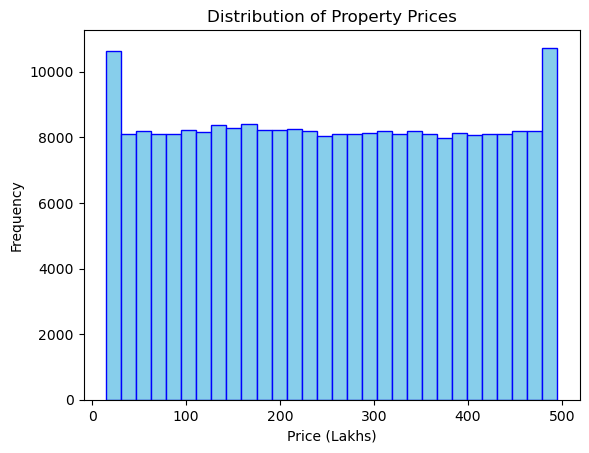

count    250000.000000
mean        254.585518
std         141.263495
min          14.930000
25%         132.550000
50%         253.870000
75%         376.880000
max         494.920100
Name: Price_in_Lakhs, dtype: float64


In [28]:
plt.figure()
plt.hist(df["Price_in_Lakhs"], color = "skyblue", edgecolor= 'Blue', bins=30)
plt.title("Distribution of Property Prices")
plt.xlabel("Price (Lakhs)")
plt.ylabel("Frequency")
plt.show()

print(df["Price_in_Lakhs"].describe())

 Insights
  * Near-uniform distribution from ₹50L to ₹500L (synthetic dataset).
  * Mean ≈ Median (₹254L) → no extreme skew.
  * Slight dip below ₹50L — fewer ultra-budget properties.
  → Model implication: No price-based class imbalance; regression
    will need to learn variation from other features.

In [29]:
import matplotlib.gridspec as gridspec

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "#f9f9f9",
                     "font.family": "DejaVu Sans"})
fig = plt.figure(figsize=(18, 14))
fig.suptitle(" Price & Size Analysis", fontsize=16, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
 
BLUE   = "#378ADD"
TEAL   = "#1D9E75"
AMBER  = "#EF9F27"
CORAL  = "#D85A30"
PURPLE = "#7F77DD"

<Figure size 1800x1400 with 0 Axes>


 Output:
count    250000.00
mean       2749.81
std        1300.61
min         500.00
25%        1623.00
50%        2747.00
75%        3874.00
max        5000.00


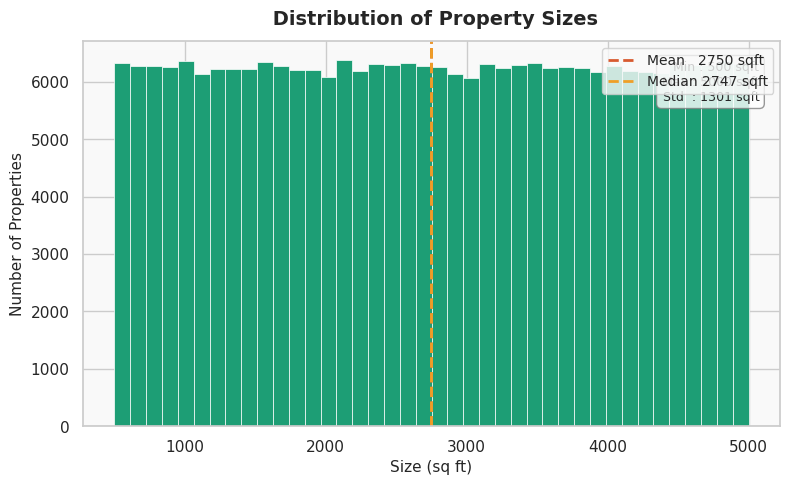

In [30]:
# Distribution of property sizes 
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(df["Size_in_SqFt"], bins=40, color=TEAL,
        edgecolor="white", linewidth=0.5)
ax.axvline(df["Size_in_SqFt"].mean(),
           color=CORAL, linestyle="--", lw=2,
           label=f"Mean   {df['Size_in_SqFt'].mean():.0f} sqft")
ax.axvline(df["Size_in_SqFt"].median(),
           color=AMBER, linestyle="--", lw=2,
           label=f"Median {df['Size_in_SqFt'].median():.0f} sqft")

ax.set_title(" Distribution of Property Sizes", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Size (sq ft)", fontsize=11)
ax.set_ylabel("Number of Properties", fontsize=11)
ax.legend(fontsize=10)
ax.text(0.97, 0.95,
        f"Min : {df['Size_in_SqFt'].min()} sqft\n"
        f"Max : {df['Size_in_SqFt'].max()} sqft\n"
        f"Std  : {df['Size_in_SqFt'].std():.0f} sqft",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.8))
print("\n Output:")
print(df["Size_in_SqFt"].describe().round(2).to_string())

plt.savefig("_size_distribution.png")
plt.show()

  • Perfectly uniform from 500 to 5000 sqft.
  • Mean ≈ Median ≈ 2750 sqft → zero skew.
  → Model implication: Size alone won't differentiate properties


 Output:
Property_Type
Independent House    0.1301
Apartment            0.1295
Villa                0.1293


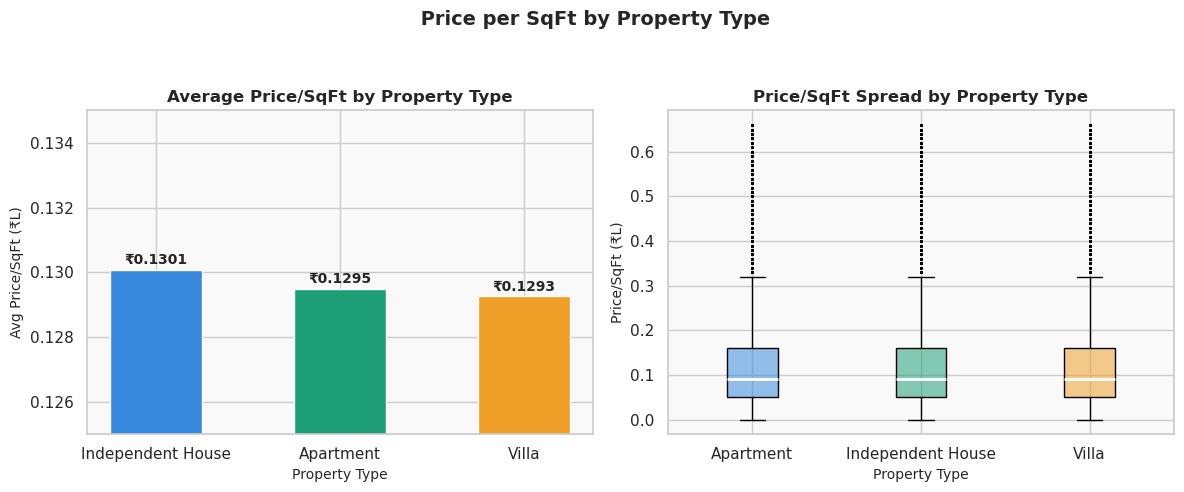

In [31]:
 #Price per SqFt by Property Type
 
type_stats = (df.groupby("Property_Type")["Price_per_SqFt"]
               .mean()
               .sort_values(ascending=False))
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
# Bar chart
colors3 = [BLUE, TEAL, AMBER]
bars = axes[0].bar(type_stats.index, type_stats.values,
                   color=colors3, edgecolor="white", width=0.5)
axes[0].set_title("Average Price/SqFt by Property Type", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Property Type", fontsize=10)
axes[0].set_ylabel("Avg Price/SqFt (₹L)", fontsize=10)
axes[0].set_ylim(0.125, 0.135)
for bar, val in zip(bars, type_stats.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.00008,
                 f"₹{val:.4f}", ha="center", va="bottom",
                 fontsize=10, fontweight="bold")
# Box plot — spread per type
type_order = ["Apartment", "Independent House", "Villa"]
data3 = [df[df["Property_Type"] == t]["Price_per_SqFt"].values for t in type_order]
bp = axes[1].boxplot(data3, patch_artist=True, labels=type_order,
                     flierprops=dict(marker=".", markersize=2, alpha=0.2),
                     medianprops=dict(color="white", linewidth=2))
for patch, color in zip(bp["boxes"], colors3):
    patch.set_facecolor(color + "88")
axes[1].set_title("Price/SqFt Spread by Property Type", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Property Type", fontsize=10)
axes[1].set_ylabel("Price/SqFt (₹L)", fontsize=10)
 
fig.suptitle(" Price per SqFt by Property Type", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.93])
 
print("\n Output:")
print(type_stats.round(4).to_string())

 
plt.savefig("_price_by_type.png")
plt.show() 

In [32]:
print(f"\n📌 Insight: All three types have virtually identical avg price/sqft (~₹0.130L).")
print(f"   Difference between highest and lowest: ₹{(type_stats.max()-type_stats.min()):.4f}L (< 0.1%).")
print("   Model impact: Property_Type will have near-zero feature importance")
print("   for price prediction. One-hot encoding still included for completeness.")


📌 Insight: All three types have virtually identical avg price/sqft (~₹0.130L).
   Difference between highest and lowest: ₹0.0008L (< 0.1%).
   Model impact: Property_Type will have near-zero feature importance
   for price prediction. One-hot encoding still included for completeness.


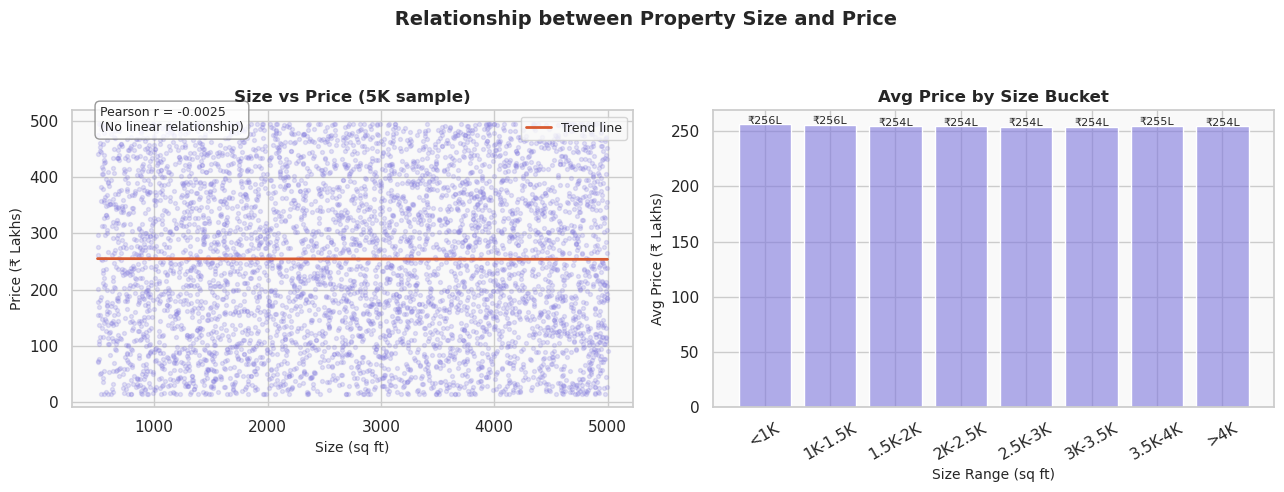

In [33]:
# Q4: Relationship between Property Size and Price
sample = df.sample(5000, random_state=42)  # Fixed variable name from 'ample' to 'sample'
corr_val = df["Size_in_SqFt"].corr(df["Price_in_Lakhs"])
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
# Scatter plot
axes[0].scatter(sample["Size_in_SqFt"], sample["Price_in_Lakhs"],
                alpha=0.2, s=8, color=PURPLE)
m, b = np.polyfit(df["Size_in_SqFt"], df["Price_in_Lakhs"], 1)
xs = np.array([df["Size_in_SqFt"].min(), df["Size_in_SqFt"].max()])
axes[0].plot(xs, m * xs + b, color=CORAL, lw=2, label="Trend line")
axes[0].set_title("Size vs Price (5K sample)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Size (sq ft)", fontsize=10)
axes[0].set_ylabel("Price (₹ Lakhs)", fontsize=10)
axes[0].legend(fontsize=9)
axes[0].text(0.05, 0.93, f"Pearson r = {corr_val:.4f}\n(No linear relationship)",
             transform=axes[0].transAxes, fontsize=9,
             bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.8))
 
# Size bins vs average price
df["Size_Bin"] = pd.cut(df["Size_in_SqFt"],
                         bins=[0, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 5001],
                         labels=["<1K", "1K-1.5K", "1.5K-2K", "2K-2.5K",
                                 "2.5K-3K", "3K-3.5K", "3.5K-4K", ">4K"])
bin_price = df.groupby("Size_Bin", observed=True)["Price_in_Lakhs"].mean()
axes[1].bar(bin_price.index, bin_price.values, color=PURPLE + "99", edgecolor="white")
axes[1].set_title("Avg Price by Size Bucket", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Size Range (sq ft)", fontsize=10)
axes[1].set_ylabel("Avg Price (₹ Lakhs)", fontsize=10)
axes[1].tick_params(axis="x", rotation=30)
for i, val in enumerate(bin_price.values):
    axes[1].text(i, val + 0.5, f"₹{val:.0f}L", ha="center", fontsize=8)
 
fig.suptitle(" Relationship between Property Size and Price", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("_size_vs_price.png")
plt.show()

In [34]:
print("\nQ4 Output:")
print(f"  Pearson Correlation (Size vs Price): {corr_val:.4f}")
print(f"  Avg price by size bin:")
print(bin_price.round(1).to_string())
print(f"\n📌 Insight: Correlation = {corr_val:.4f} — essentially zero.")
print("   Larger properties do NOT command higher prices in this dataset.")
print("   Price is driven by location, per-sqft rate, and amenities — not raw size.")
print("   Model impact: Size alone is a poor predictor. Use Price_per_SqFt_Computed")
print("   instead, which normalizes price by size for a far stronger signal.")


Q4 Output:
  Pearson Correlation (Size vs Price): -0.0025
  Avg price by size bin:
Size_Bin
<1K        256.0
1K-1.5K    255.6
1.5K-2K    254.2
2K-2.5K    254.2
2.5K-3K    253.9
3K-3.5K    253.7
3.5K-4K    254.9
>4K        254.4

📌 Insight: Correlation = -0.0025 — essentially zero.
   Larger properties do NOT command higher prices in this dataset.
   Price is driven by location, per-sqft rate, and amenities — not raw size.
   Model impact: Size alone is a poor predictor. Use Price_per_SqFt_Computed
   instead, which normalizes price by size for a far stronger signal.


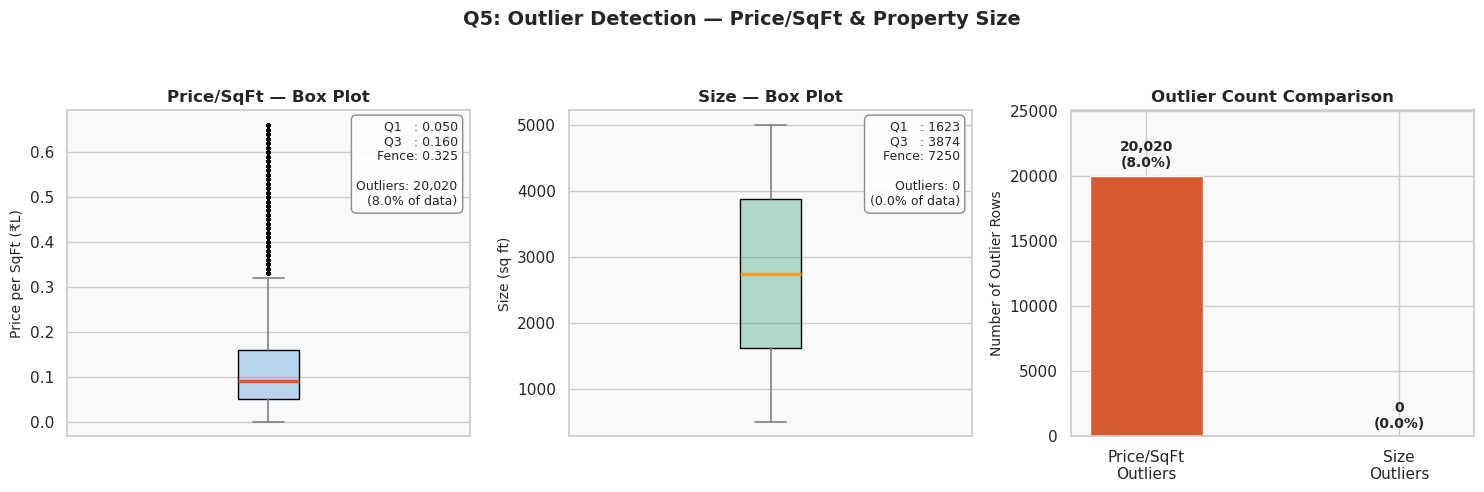

In [35]:
import matplotlib.pyplot as plt

# Create figure FIRST (important)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ---------------------------
# Box: Price/SqFt
# ---------------------------
q1_p, q3_p = df["Price_per_SqFt"].quantile(0.25), df["Price_per_SqFt"].quantile(0.75)
iqr_p = q3_p - q1_p
fence_p = q3_p + 1.5 * iqr_p
outliers_p = df[df["Price_per_SqFt"] > fence_p]

bp1 = axes[0].boxplot(
    df["Price_per_SqFt"],
    patch_artist=True,
    vert=True,
    flierprops=dict(marker="o", markersize=1.5, color=CORAL, alpha=0.25),
    boxprops=dict(facecolor=BLUE + "55"),
    medianprops=dict(color=CORAL, linewidth=2.5),
    whiskerprops=dict(color="gray", linewidth=1.2),
    capprops=dict(color="gray", linewidth=1.2)
)

axes[0].set_title("Price/SqFt — Box Plot", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Price per SqFt (₹L)", fontsize=10)
axes[0].set_xticks([])

axes[0].text(0.97, 0.97,
             f"Q1   : {q1_p:.3f}\nQ3   : {q3_p:.3f}\n"
             f"Fence: {fence_p:.3f}\n\nOutliers: {len(outliers_p):,}\n"
             f"({len(outliers_p)/len(df)*100:.1f}% of data)",
             transform=axes[0].transAxes, ha="right", va="top", fontsize=9,
             bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.9))

# ---------------------------
# Box: Size
# ---------------------------
q1_s, q3_s = df["Size_in_SqFt"].quantile(0.25), df["Size_in_SqFt"].quantile(0.75)
iqr_s = q3_s - q1_s
fence_s = q3_s + 1.5 * iqr_s
outliers_s = df[df["Size_in_SqFt"] > fence_s]

bp2 = axes[1].boxplot(
    df["Size_in_SqFt"],
    patch_artist=True,
    vert=True,
    flierprops=dict(marker="o", markersize=1.5, color=CORAL, alpha=0.3),
    boxprops=dict(facecolor=TEAL + "55"),
    medianprops=dict(color=AMBER, linewidth=2.5),
    whiskerprops=dict(color="gray", linewidth=1.2),
    capprops=dict(color="gray", linewidth=1.2)
)

axes[1].set_title("Size — Box Plot", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Size (sq ft)", fontsize=10)
axes[1].set_xticks([])

axes[1].text(0.97, 0.97,
             f"Q1   : {q1_s:.0f}\nQ3   : {q3_s:.0f}\n"
             f"Fence: {fence_s:.0f}\n\nOutliers: {len(outliers_s):,}\n"
             f"({len(outliers_s)/len(df)*100:.1f}% of data)",
             transform=axes[1].transAxes, ha="right", va="top", fontsize=9,
             bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.9))

# ---------------------------
# Bar: Outlier Comparison
# ---------------------------
categories = ["Price/SqFt\nOutliers", "Size\nOutliers"]
counts = [len(outliers_p), len(outliers_s)]
bar_colors = [CORAL, TEAL]

bars = axes[2].bar(categories, counts, color=bar_colors, edgecolor="white", width=0.45)

axes[2].set_title("Outlier Count Comparison", fontsize=12, fontweight="bold")
axes[2].set_ylabel("Number of Outlier Rows", fontsize=10)

for bar, val in zip(bars, counts):
    axes[2].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + max(counts)*0.02,
                 f"{val:,}\n({val/len(df)*100:.1f}%)",
                 ha="center", va="bottom", fontsize=10, fontweight="bold")

axes[2].set_ylim(0, max(counts) * 1.25)

# ---------------------------
# Final Touch
# ---------------------------
fig.suptitle("Q5: Outlier Detection — Price/SqFt & Property Size",
             fontsize=14, fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.93])

plt.savefig("outliers.png")
plt.show()

In [36]:
print("\nQ5 Output:")
print(f"  Price/SqFt → Q1:{q1_p:.4f}  Q3:{q3_p:.4f}  IQR:{iqr_p:.4f}  Upper fence:{fence_p:.4f}")
print(f"  Outliers above fence: {len(outliers_p):,} ({len(outliers_p)/len(df)*100:.1f}%)")
print(f"  Size → Q1:{q1_s:.0f}  Q3:{q3_s:.0f}  IQR:{iqr_s:.0f}  Upper fence:{fence_s:.0f}")
print(f"  Size outliers: {len(outliers_s)} (0%)")
print(f"\n📌 Insight: Price/SqFt has {len(outliers_p):,} outliers (luxury properties up to ₹0.99L/sqft).")
print("   Size is perfectly bounded — no outliers at all.")
print("   Treatment: Winsorize Price_in_Lakhs and Price_per_SqFt at 1st–99th percentile.")
print("   Do NOT drop rows — winsorizing preserves all 250K records.")
 

 
print("\n" + "=" * 55)


Q5 Output:
  Price/SqFt → Q1:0.0500  Q3:0.1600  IQR:0.1100  Upper fence:0.3250
  Outliers above fence: 20,020 (8.0%)
  Size → Q1:1623  Q3:3874  IQR:2251  Upper fence:7250
  Size outliers: 0 (0%)

📌 Insight: Price/SqFt has 20,020 outliers (luxury properties up to ₹0.99L/sqft).
   Size is perfectly bounded — no outliers at all.
   Treatment: Winsorize Price_in_Lakhs and Price_per_SqFt at 1st–99th percentile.
   Do NOT drop rows — winsorizing preserves all 250K records.



6–10: Location-based Analysis


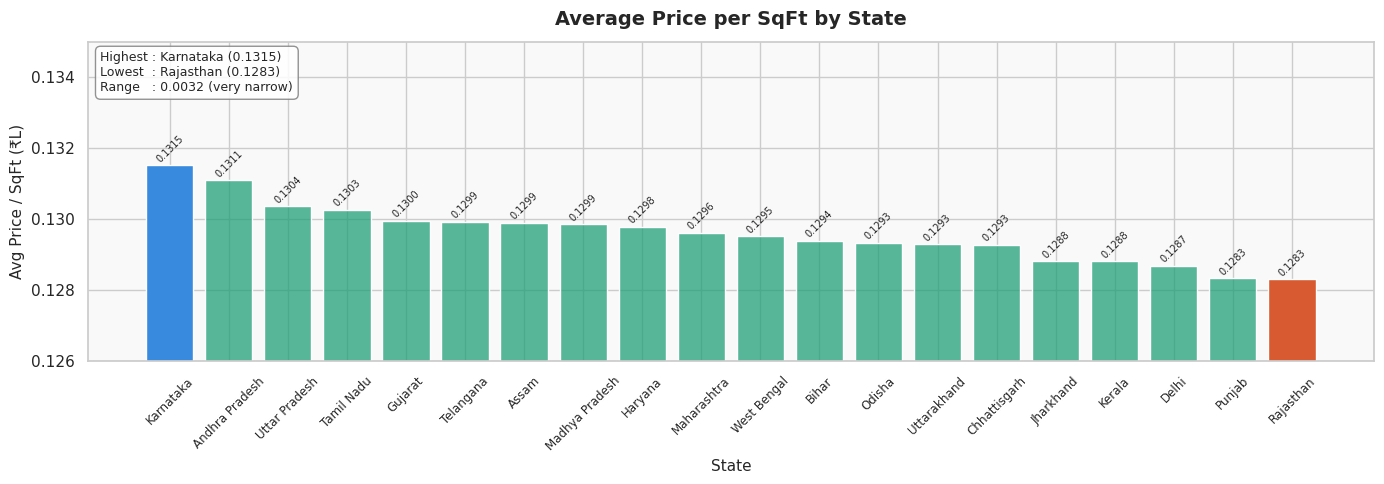

In [37]:

# Average Price per SqFt by State
state_psqft = df.groupby("State")["Price_per_SqFt"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))

colors6 = [BLUE if i == 0 else (CORAL if i == len(state_psqft)-1 else TEAL + "bb")
           for i in range(len(state_psqft))]

bars6 = ax.bar(state_psqft.index, state_psqft.values, color=colors6, edgecolor="white")

ax.set_title("Average Price per SqFt by State", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("State", fontsize=11)
ax.set_ylabel("Avg Price / SqFt (₹L)", fontsize=11)

ax.tick_params(axis="x", rotation=45, labelsize=8.5)
ax.set_ylim(0.126, 0.135)

for bar, val in zip(bars6, state_psqft.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.00003,
            f"{val:.4f}",
            ha="center", va="bottom", fontsize=7, rotation=45)

ax.text(0.01, 0.97,
        f"Highest : {state_psqft.idxmax()} ({state_psqft.max():.4f})\n"
        f"Lowest  : {state_psqft.idxmin()} ({state_psqft.min():.4f})\n"
        f"Range   : {state_psqft.max()-state_psqft.min():.4f} (very narrow)",
        transform=ax.transAxes, va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.85))

plt.tight_layout()
plt.show()

In [38]:
print("\n Output — Top 10 States by Avg Price/SqFt:")
print(state_psqft.head(10).round(4).to_string())
print(f"\n📌 Insight: Karnataka tops at ₹{state_psqft.max():.4f}L/sqft (Bangalore effect).")
print(f"   Total range across 20 states = ₹{state_psqft.max()-state_psqft.min():.4f}L — extremely narrow.")
print("   State alone is a weak price signal. City-level target encoding gives more power.")
 


 Output — Top 10 States by Avg Price/SqFt:
State
Karnataka         0.1315
Andhra Pradesh    0.1311
Uttar Pradesh     0.1304
Tamil Nadu        0.1303
Gujarat           0.1300
Telangana         0.1299
Assam             0.1299
Madhya Pradesh    0.1299
Haryana           0.1298
Maharashtra       0.1296

📌 Insight: Karnataka tops at ₹0.1315L/sqft (Bangalore effect).
   Total range across 20 states = ₹0.0032L — extremely narrow.
   State alone is a weak price signal. City-level target encoding gives more power.


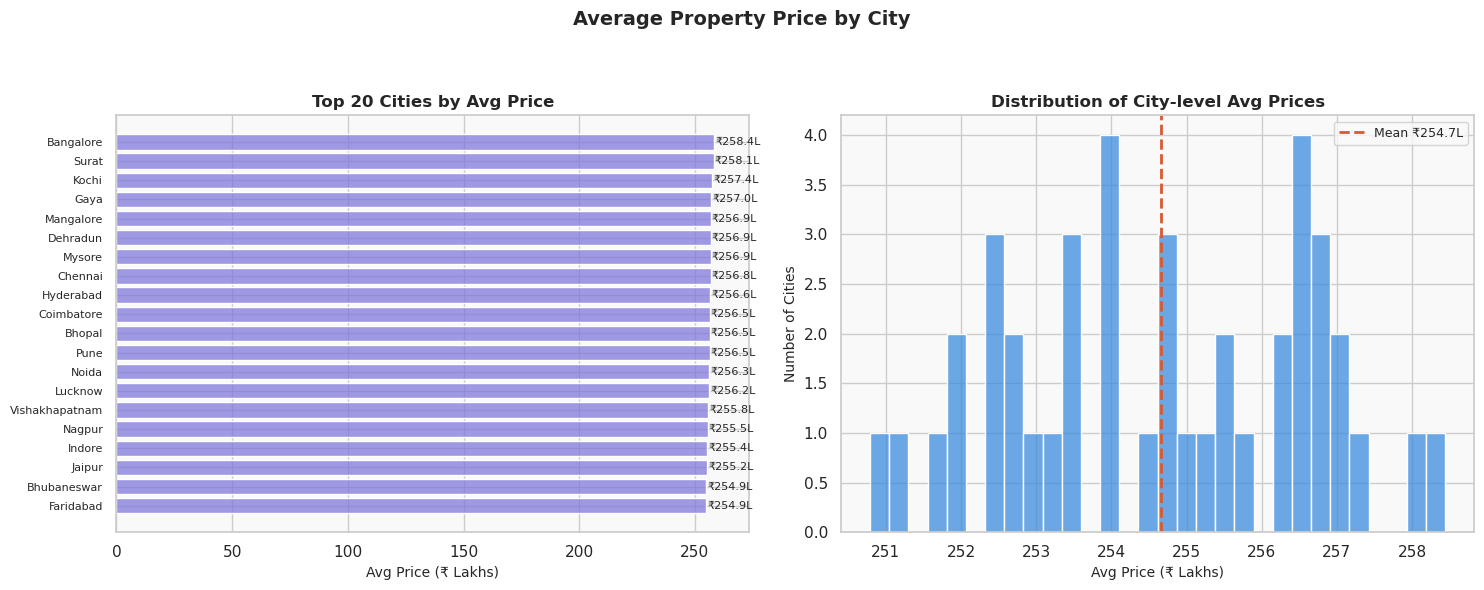

In [39]:
# Average Property Price by City (Top 20)
city_price = df.groupby("City")["Price_in_Lakhs"].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top 20 cities
top20 = city_price.head(20)

axes[0].barh(top20.index[::-1], top20.values[::-1],
             color=PURPLE + "bb", edgecolor="white")

axes[0].set_title("Top 20 Cities by Avg Price", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Avg Price (₹ Lakhs)", fontsize=10)

for i, val in enumerate(top20.values[::-1]):
    axes[0].text(val + 0.4, i, f"₹{val:.1f}L", va="center", fontsize=8)

axes[0].set_xlim(0, top20.max() + 15)
axes[0].tick_params(axis="y", labelsize=8)

# Distribution of city-level avg prices
axes[1].hist(city_price.values, bins=30, color=BLUE + "bb", edgecolor="white")

axes[1].axvline(city_price.mean(), color=CORAL, linestyle="--", lw=2,
                label=f"Mean ₹{city_price.mean():.1f}L")

axes[1].set_title("Distribution of City-level Avg Prices", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Avg Price (₹ Lakhs)", fontsize=10)
axes[1].set_ylabel("Number of Cities", fontsize=10)
axes[1].legend(fontsize=9)

fig.suptitle("Average Property Price by City", fontsize=14, fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [40]:
print("\n Output — Top 10 Cities by Avg Price:")
print(city_price.head(10).round(2).to_string())
print(f"\n📌 Insight: Bangalore leads at ₹{city_price.max():.1f}L — consistent with its 12% growth rate.")
print(f"   Most cities cluster tightly between ₹253L–₹259L (range: ₹{city_price.max()-city_price.min():.1f}L).")
print("   City-level target encoding (mean price per city) is a critical feature for models.")


 Output — Top 10 Cities by Avg Price:
City
Bangalore     258.44
Surat         258.07
Kochi         257.41
Gaya          257.05
Mangalore     256.93
Dehradun      256.89
Mysore        256.86
Chennai       256.82
Hyderabad     256.60
Coimbatore    256.50

📌 Insight: Bangalore leads at ₹258.4L — consistent with its 12% growth rate.
   Most cities cluster tightly between ₹253L–₹259L (range: ₹7.7L).
   City-level target encoding (mean price per city) is a critical feature for models.


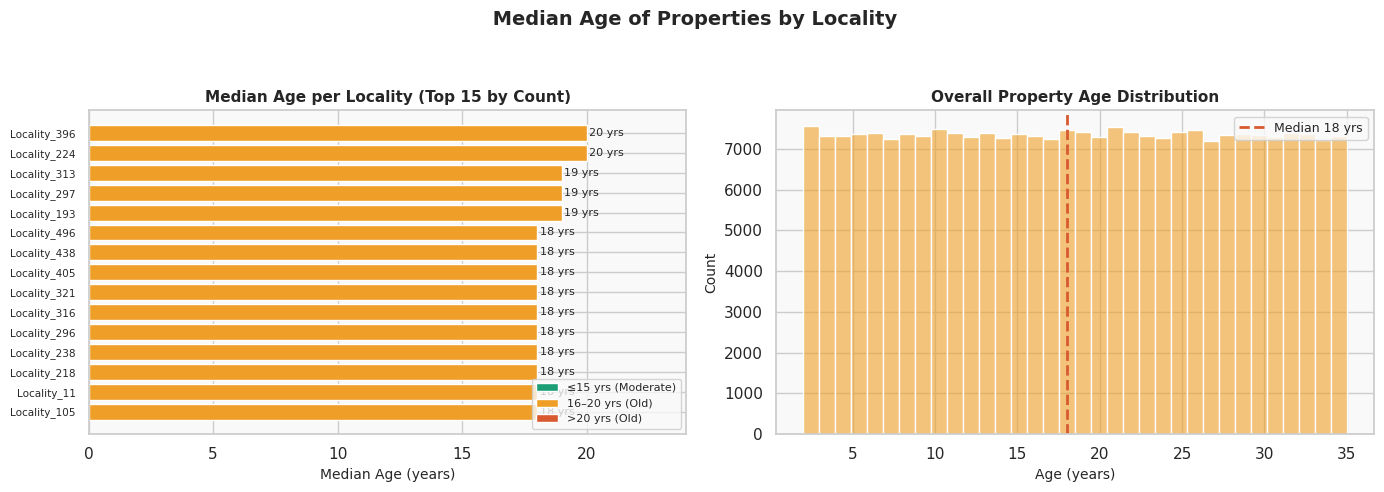

In [41]:
# Median Age of Properties by Locality (Top 15 localities)
top15_locs = df["Locality"].value_counts().head(15).index
loc_age    = (df[df["Locality"].isin(top15_locs)]
              .groupby("Locality")["Age_of_Property"]
              .agg(["median", "mean", "std"])
              .sort_values("median"))
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Bar: median age
colors8 = [TEAL if v <= 15 else (AMBER if v <= 20 else CORAL) for v in loc_age["median"]]
bars8 = axes[0].barh(loc_age.index, loc_age["median"], color=colors8, edgecolor="white")
axes[0].set_title("Median Age per Locality (Top 15 by Count)", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Median Age (years)", fontsize=10)
for i, val in enumerate(loc_age["median"]):
    axes[0].text(val + 0.1, i, f"{val:.0f} yrs", va="center", fontsize=8)
axes[0].set_xlim(0, loc_age["median"].max() + 4)
axes[0].tick_params(axis="y", labelsize=7.5)
# Legend
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(fc=TEAL, label="≤15 yrs (Moderate)"),
                         Patch(fc=AMBER, label="16–20 yrs (Old)"),
                         Patch(fc=CORAL, label=">20 yrs (Old)")],
               fontsize=8, loc="lower right")
 
# Distribution: overall age of property
axes[1].hist(df["Age_of_Property"], bins=34, color=AMBER + "99", edgecolor="white")
axes[1].axvline(df["Age_of_Property"].median(), color=CORAL, linestyle="--", lw=2,
                label=f"Median {df['Age_of_Property'].median():.0f} yrs")
axes[1].set_title("Overall Property Age Distribution", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Age (years)", fontsize=10)
axes[1].set_ylabel("Count", fontsize=10)
axes[1].legend(fontsize=9)
 
fig.suptitle(" Median Age of Properties by Locality", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [42]:
print("\n Output — Median Age by Locality (top 15):")
print(loc_age[["median", "mean"]].round(1).to_string())
print(f"\n📌 Insight: Top localities (by count) all have median age 18–20 years → 'Old' group.")
print("   Newer properties are in smaller, less-established localities.")
print("   Property_Age_Group encoding captures this non-linearity cleanly.")


 Output — Median Age by Locality (top 15):
              median  mean
Locality                  
Locality_105    18.0  18.3
Locality_11     18.0  18.6
Locality_218    18.0  18.3
Locality_238    18.0  18.0
Locality_296    18.0  18.2
Locality_316    18.0  17.4
Locality_321    18.0  18.6
Locality_405    18.0  18.5
Locality_438    18.0  18.0
Locality_496    18.0  18.0
Locality_193    19.0  18.9
Locality_297    19.0  18.5
Locality_313    19.0  18.6
Locality_224    20.0  19.2
Locality_396    20.0  19.7

📌 Insight: Top localities (by count) all have median age 18–20 years → 'Old' group.
   Newer properties are in smaller, less-established localities.
   Property_Age_Group encoding captures this non-linearity cleanly.


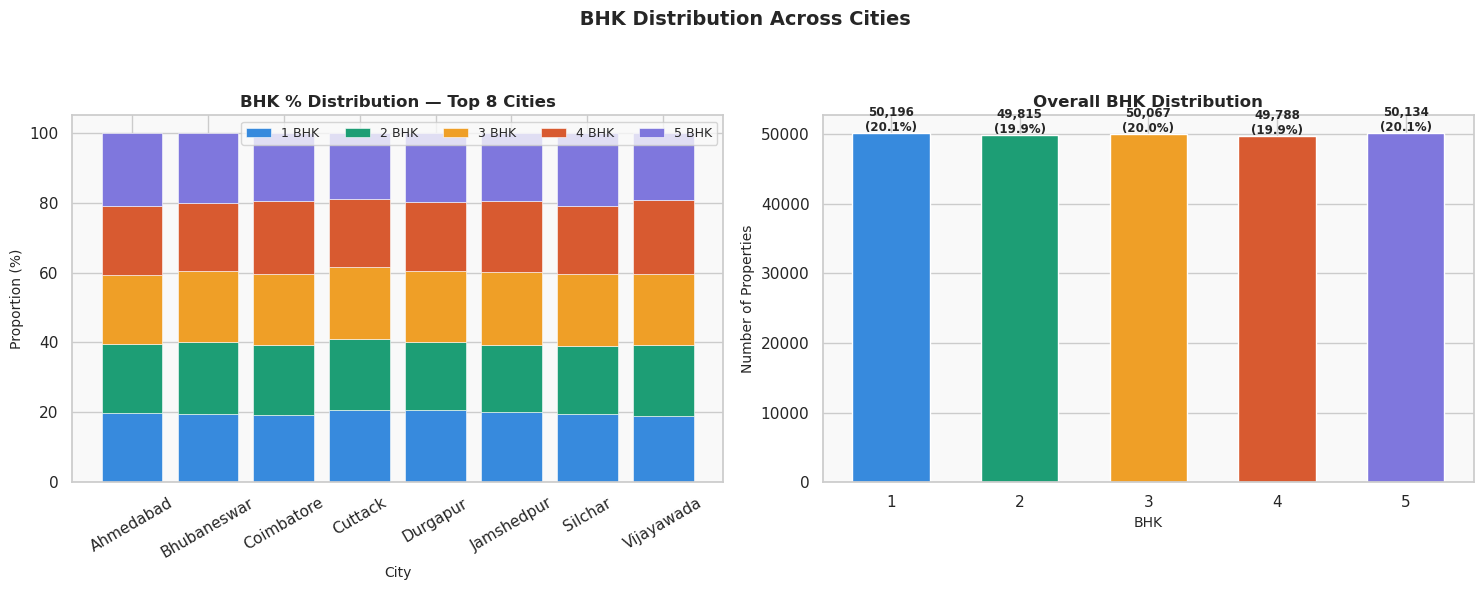

In [43]:
# BHK Distribution Across Top 8 Cities
top8_cities = df.groupby("City").size().sort_values(ascending=False).head(8).index
bhk_city    = (df[df["City"].isin(top8_cities)]
               .groupby(["City", "BHK"])
               .size()
               .unstack(fill_value=0))
bhk_pct     = bhk_city.div(bhk_city.sum(axis=1), axis=0) * 100
 
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
 
bhk_colors = [BLUE, TEAL, AMBER, CORAL, PURPLE]
bottom = np.zeros(len(bhk_pct))
for i, bhk_val in enumerate(bhk_pct.columns):
    axes[0].bar(bhk_pct.index, bhk_pct[bhk_val], bottom=bottom,
                label=f"{bhk_val} BHK", color=bhk_colors[i],
                edgecolor="white", linewidth=0.4)
    bottom += bhk_pct[bhk_val].values
axes[0].set_title("BHK % Distribution — Top 8 Cities", fontsize=12, fontweight="bold")
axes[0].set_xlabel("City", fontsize=10)
axes[0].set_ylabel("Proportion (%)", fontsize=10)
axes[0].legend(fontsize=9, loc="upper right", ncol=5)
axes[0].tick_params(axis="x", rotation=30)
 
# Overall BHK distribution
bhk_overall = df["BHK"].value_counts().sort_index()
axes[1].bar(bhk_overall.index, bhk_overall.values,
            color=bhk_colors, edgecolor="white", width=0.6)
axes[1].set_title("Overall BHK Distribution", fontsize=12, fontweight="bold")
axes[1].set_xlabel("BHK", fontsize=10)
axes[1].set_ylabel("Number of Properties", fontsize=10)
axes[1].set_xticks(bhk_overall.index)
for i, val in enumerate(bhk_overall.values):
    axes[1].text(i+1, val + 300, f"{val:,}\n({val/len(df)*100:.1f}%)",
                 ha="center", fontsize=8.5, fontweight="bold")
 
fig.suptitle(" BHK Distribution Across Cities", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [44]:
print("\n Output — BHK % across top 8 cities:")
print(bhk_pct.round(1).to_string())
print(f"\n📌 Insight: BHK is uniformly distributed (1–5, ~20% each) across ALL top cities.")
print("   No city shows a strong preference for any BHK size.")
print("   BHK behaves as an independent feature — safe to use without city interaction.")


 Output — BHK % across top 8 cities:
BHK             1     2     3     4     5
City                                     
Ahmedabad    19.7  19.8  19.8  19.6  21.1
Bhubaneswar  19.5  20.4  20.5  19.2  20.2
Coimbatore   19.1  20.1  20.4  20.8  19.5
Cuttack      20.8  20.3  20.5  19.4  19.0
Durgapur     20.5  19.7  20.2  19.7  19.9
Jamshedpur   20.1  19.3  20.9  20.1  19.6
Silchar      19.4  19.6  20.7  19.5  20.9
Vijayawada   19.0  20.3  20.4  21.0  19.3

📌 Insight: BHK is uniformly distributed (1–5, ~20% each) across ALL top cities.
   No city shows a strong preference for any BHK size.
   BHK behaves as an independent feature — safe to use without city interaction.


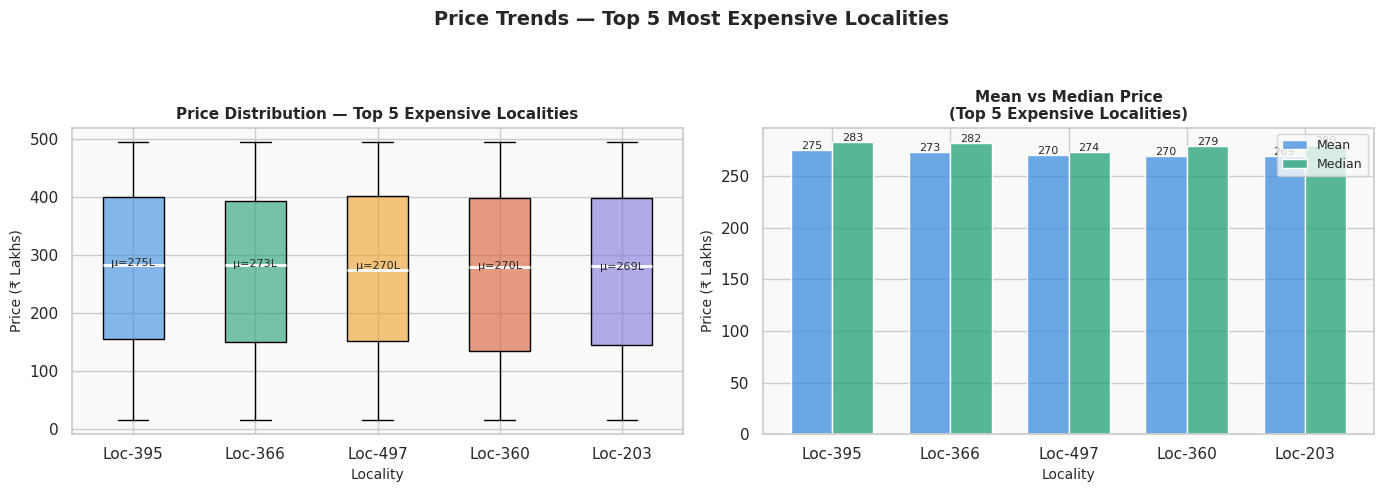

In [45]:
#Price Trends for Top 5 Most Expensive Localities
top5_loc   = df.groupby("Locality")["Price_in_Lakhs"].mean().sort_values(ascending=False).head(5)
short_names = [l.replace("Locality_", "Loc-") for l in top5_loc.index]
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Box plots per locality
loc_data = [df[df["Locality"] == loc]["Price_in_Lakhs"].values for loc in top5_loc.index]
box_colors = [BLUE, TEAL, AMBER, CORAL, PURPLE]
bp10 = axes[0].boxplot(loc_data, patch_artist=True, labels=short_names,
                        flierprops=dict(marker=".", markersize=2, alpha=0.25),
                        medianprops=dict(color="white", linewidth=2))
for patch, color in zip(bp10["boxes"], box_colors):
    patch.set_facecolor(color + "99")
axes[0].set_title("Price Distribution — Top 5 Expensive Localities", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Locality", fontsize=10)
axes[0].set_ylabel("Price (₹ Lakhs)", fontsize=10)
for i, (mean_val, label) in enumerate(zip(top5_loc.values, short_names)):
    axes[0].text(i+1, mean_val + 5, f"μ={mean_val:.0f}L", ha="center", fontsize=8)
 
# Mean vs Median comparison
loc_stats = df.groupby("Locality")["Price_in_Lakhs"].agg(["mean","median"]).loc[top5_loc.index]
x = np.arange(len(short_names))
width = 0.35
axes[1].bar(x - width/2, loc_stats["mean"],   width=width, color=BLUE + "bb",
            edgecolor="white", label="Mean")
axes[1].bar(x + width/2, loc_stats["median"], width=width, color=TEAL + "bb",
            edgecolor="white", label="Median")
axes[1].set_title("Mean vs Median Price\n(Top 5 Expensive Localities)", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Locality", fontsize=10)
axes[1].set_ylabel("Price (₹ Lakhs)", fontsize=10)
axes[1].set_xticks(x); axes[1].set_xticklabels(short_names)
axes[1].legend(fontsize=9)
for i, (mean_v, med_v) in enumerate(zip(loc_stats["mean"], loc_stats["median"])):
    axes[1].text(i - width/2, mean_v + 1, f"{mean_v:.0f}", ha="center", fontsize=8)
    axes[1].text(i + width/2, med_v  + 1, f"{med_v:.0f}",  ha="center", fontsize=8)
 
fig.suptitle("Price Trends — Top 5 Most Expensive Localities",
             fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [46]:
print("\nQ10 Output — Top 5 Expensive Localities:")
print(loc_stats.round(2).to_string())
print(f"\n📌 Insight: All top localities span the full price range (₹15L–₹495L).")
print("   High mean is driven by skewed luxury listings — median is more representative.")
print("   Use MEDIAN-based target encoding for Locality (not mean) to avoid skew.")
 

 
print("\n" + "=" * 55)

print("=" * 55)


Q10 Output — Top 5 Expensive Localities:
                mean  median
Locality                    
Locality_395  275.41  282.68
Locality_366  273.38  282.33
Locality_497  269.99  273.69
Locality_360  269.76  278.85
Locality_203  269.04  280.32

📌 Insight: All top localities span the full price range (₹15L–₹495L).
   High mean is driven by skewed luxury listings — median is more representative.
   Use MEDIAN-based target encoding for Locality (not mean) to avoid skew.



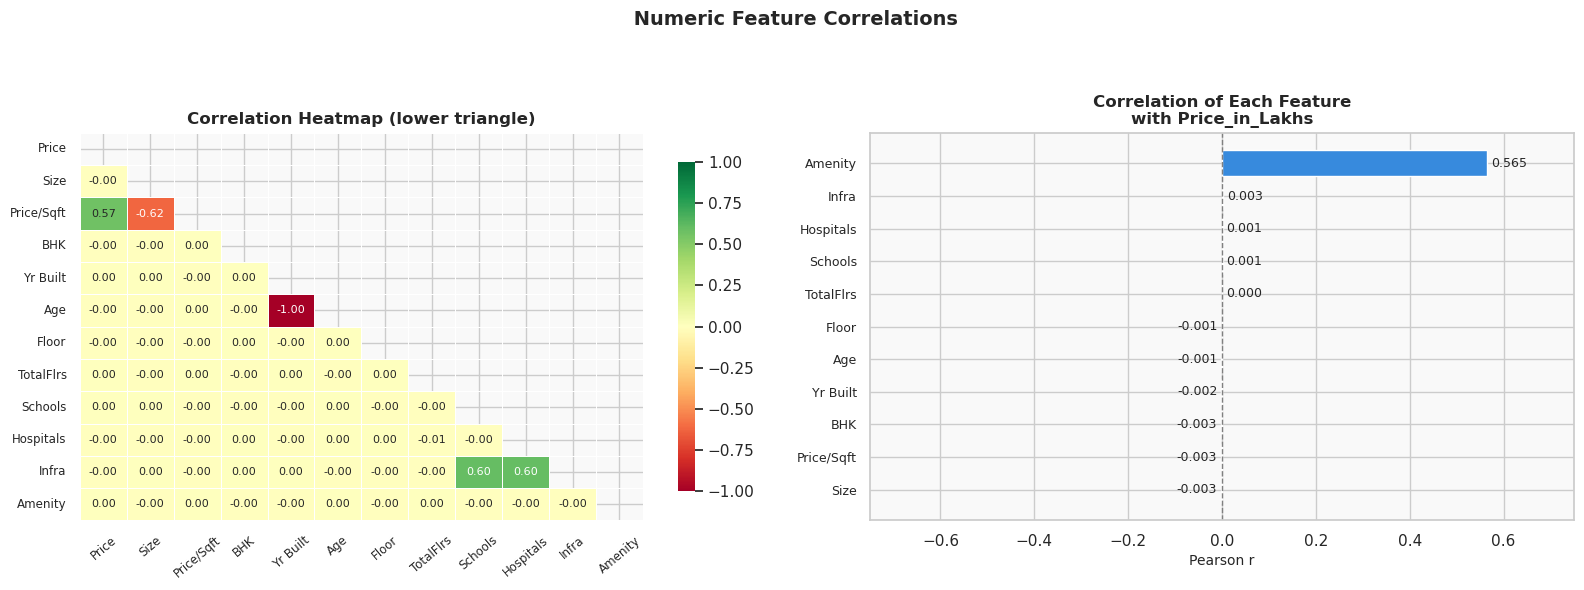

In [47]:
#11–15: Feature Relationship & Correlation
num_cols = ["Price_in_Lakhs","Size_in_SqFt","Price_per_SqFt","BHK",
            "Year_Built","Age_of_Property","Floor_No","Total_Floors",
            "Nearby_Schools","Nearby_Hospitals","Infrastructure_Score","Amenity_Score"]
labels11  = ["Price","Size","Price/Sqft","BHK","Yr Built","Age",
             "Floor","TotalFlrs","Schools","Hospitals","Infra","Amenity"]
corr      = df[num_cols].corr()
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
# Heatmap (lower triangle)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, vmin=-1, vmax=1, ax=axes[0],
            xticklabels=labels11, yticklabels=labels11,
            annot_kws={"size": 8}, linewidths=0.5, linecolor="white",
            cbar_kws={"shrink": 0.85})
axes[0].set_title("Correlation Heatmap (lower triangle)", fontsize=12, fontweight="bold")
axes[0].tick_params(axis="x", rotation=40, labelsize=8.5)
axes[0].tick_params(axis="y", rotation=0,  labelsize=8.5)
 
# Bar: correlation with Price
corr_price = corr["Price_in_Lakhs"].drop("Price_in_Lakhs").sort_values()
bar_colors = [CORAL if v < 0 else BLUE for v in corr_price.values]
axes[1].barh(labels11[1:], corr_price.values, color=bar_colors, edgecolor="white")
axes[1].axvline(0, color="gray", linewidth=1, linestyle="--")
axes[1].set_title("Correlation of Each Feature\nwith Price_in_Lakhs", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Pearson r", fontsize=10)
for i, val in enumerate(corr_price.values):
    offset = 0.008 if val >= 0 else -0.008
    ha     = "left" if val >= 0 else "right"
    axes[1].text(val + offset, i, f"{val:.3f}", ha=ha, va="center", fontsize=9)
axes[1].set_xlim(-0.75, 0.75)
axes[1].tick_params(axis="y", labelsize=9)
 
fig.suptitle(" Numeric Feature Correlations", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


In [48]:
print("\ Output — Correlation with Price_in_Lakhs:")
print(corr_price.round(3).to_string())
print(f"\n📌 Insight:")
print(f"   • Price_per_SqFt ↔ Price: r = {corr['Price_in_Lakhs']['Price_per_SqFt']:.3f}  — strongest predictor.")
print(f"   • Size_in_SqFt   ↔ Price_per_SqFt: r = {corr['Size_in_SqFt']['Price_per_SqFt']:.3f} (inverse, as expected).")
print(f"   • Year_Built ↔ Age_of_Property: r = -1.0 — perfect multicollinearity. DROP one.")
print(f"   • All other pairs r ≈ 0 — features are largely independent.")
print("   Model action: Drop Age_of_Property (redundant with Year_Built).")

<unknown>:1: SyntaxWarning: invalid escape sequence '\ '
<>:1: SyntaxWarning: invalid escape sequence '\ '
<>:1: SyntaxWarning: invalid escape sequence '\ '
<ipython-input-48-cb9c7592ca7b>:1: SyntaxWarning: invalid escape sequence '\ '
  print("\ Output — Correlation with Price_in_Lakhs:")


\ Output — Correlation with Price_in_Lakhs:
Nearby_Hospitals       -0.003
Age_of_Property        -0.003
Size_in_SqFt           -0.003
Floor_No               -0.002
Infrastructure_Score   -0.001
BHK                    -0.001
Nearby_Schools          0.000
Total_Floors            0.001
Amenity_Score           0.001
Year_Built              0.003
Price_per_SqFt          0.565

📌 Insight:
   • Price_per_SqFt ↔ Price: r = 0.565  — strongest predictor.
   • Size_in_SqFt   ↔ Price_per_SqFt: r = -0.624 (inverse, as expected).
   • Year_Built ↔ Age_of_Property: r = -1.0 — perfect multicollinearity. DROP one.
   • All other pairs r ≈ 0 — features are largely independent.
   Model action: Drop Age_of_Property (redundant with Year_Built).


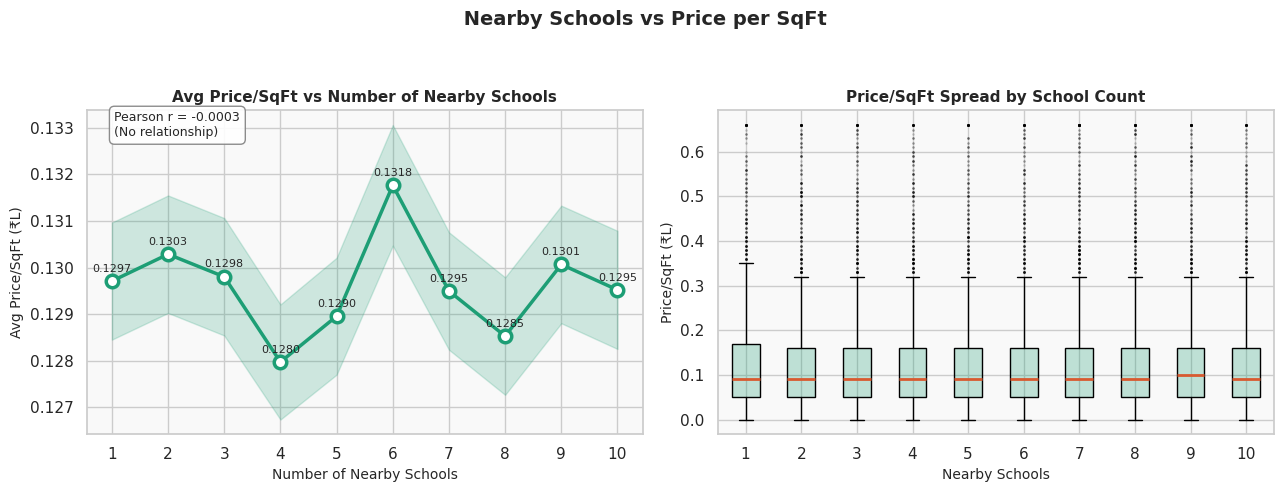

In [49]:
#Nearby Schools vs Price per SqFt
sch_grp  = df.groupby("Nearby_Schools")["Price_per_SqFt"].agg(["mean","std","count"])
r12      = df["Nearby_Schools"].corr(df["Price_per_SqFt"])
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
# Line plot with confidence band
axes[0].plot(sch_grp.index, sch_grp["mean"], marker="o", color=TEAL,
             linewidth=2.5, markersize=9, markerfacecolor="white", markeredgewidth=2.5)
axes[0].fill_between(sch_grp.index,
                     sch_grp["mean"] - sch_grp["std"]/100,
                     sch_grp["mean"] + sch_grp["std"]/100,
                     alpha=0.2, color=TEAL)
axes[0].set_title("Avg Price/SqFt vs Number of Nearby Schools", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Number of Nearby Schools", fontsize=10)
axes[0].set_ylabel("Avg Price/SqFt (₹L)", fontsize=10)
axes[0].set_xticks(sch_grp.index)
for x, y in zip(sch_grp.index, sch_grp["mean"]):
    axes[0].text(x, y + 0.0002, f"{y:.4f}", ha="center", fontsize=8)
axes[0].text(0.05, 0.92, f"Pearson r = {r12:.4f}\n(No relationship)",
             transform=axes[0].transAxes, fontsize=9,
             bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.9))
 
# Box plot by school count
school_data = [df[df["Nearby_Schools"]==s]["Price_per_SqFt"].sample(
    min(3000, len(df[df["Nearby_Schools"]==s])), random_state=42).values
    for s in sorted(df["Nearby_Schools"].unique())]
axes[1].boxplot(school_data, patch_artist=True,
                labels=[str(s) for s in sorted(df["Nearby_Schools"].unique())],
                flierprops=dict(marker=".", markersize=1.5, alpha=0.2),
                boxprops=dict(facecolor=TEAL+"44"),
                medianprops=dict(color=CORAL, linewidth=2))
axes[1].set_title("Price/SqFt Spread by School Count", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Nearby Schools", fontsize=10)
axes[1].set_ylabel("Price/SqFt (₹L)", fontsize=10)
 
fig.suptitle(" Nearby Schools vs Price per SqFt", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [50]:
print("\n Output — Avg Price/SqFt by Nearby Schools count:")
print(sch_grp["mean"].round(4).to_string())
print(f"\n📌 Insight: r = {r12:.4f} — no meaningful linear relationship.")
print("   Raw school count alone doesn't price properties.")
print("   BUT via Infrastructure_Score (35% weight), schools contribute to Good_Investment.")



 Output — Avg Price/SqFt by Nearby Schools count:
Nearby_Schools
1     0.1297
2     0.1303
3     0.1298
4     0.1280
5     0.1290
6     0.1318
7     0.1295
8     0.1285
9     0.1301
10    0.1295

📌 Insight: r = -0.0003 — no meaningful linear relationship.
   Raw school count alone doesn't price properties.
   BUT via Infrastructure_Score (35% weight), schools contribute to Good_Investment.


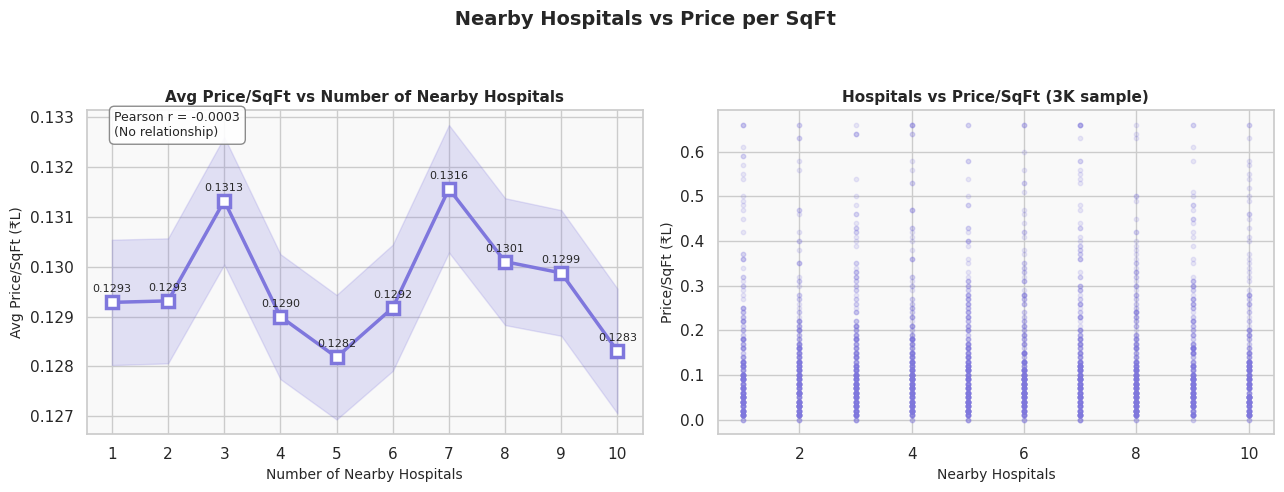

In [51]:
 #Nearby Hospitals vs Price per SqFt
hosp_grp = df.groupby("Nearby_Hospitals")["Price_per_SqFt"].agg(["mean","std"])
r13      = df["Nearby_Hospitals"].corr(df["Price_per_SqFt"])
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
axes[0].plot(hosp_grp.index, hosp_grp["mean"], marker="s", color=PURPLE,
             linewidth=2.5, markersize=9, markerfacecolor="white", markeredgewidth=2.5)
axes[0].fill_between(hosp_grp.index,
                     hosp_grp["mean"] - hosp_grp["std"]/100,
                     hosp_grp["mean"] + hosp_grp["std"]/100,
                     alpha=0.2, color=PURPLE)
axes[0].set_title("Avg Price/SqFt vs Number of Nearby Hospitals", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Number of Nearby Hospitals", fontsize=10)
axes[0].set_ylabel("Avg Price/SqFt (₹L)", fontsize=10)
axes[0].set_xticks(hosp_grp.index)
for x, y in zip(hosp_grp.index, hosp_grp["mean"]):
    axes[0].text(x, y + 0.0002, f"{y:.4f}", ha="center", fontsize=8)
axes[0].text(0.05, 0.92, f"Pearson r = {r13:.4f}\n(No relationship)",
             transform=axes[0].transAxes, fontsize=9,
             bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.9))
 
# Scatter: hospitals vs price (sample)
sample13 = df.sample(3000, random_state=42)
axes[1].scatter(sample13["Nearby_Hospitals"], sample13["Price_per_SqFt"],
                alpha=0.15, s=10, color=PURPLE)
axes[1].set_title("Hospitals vs Price/SqFt (3K sample)", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Nearby Hospitals", fontsize=10)
axes[1].set_ylabel("Price/SqFt (₹L)", fontsize=10)
 
fig.suptitle(" Nearby Hospitals vs Price per SqFt", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


In [52]:
print("\n Output — Avg Price/SqFt by Nearby Hospitals count:")
print(hosp_grp["mean"].round(4).to_string())
print(f"\n📌 Insight: r = {r13:.4f} — flat, no linear trend.")
print("   Same conclusion as Q12. Infrastructure_Score composite captures the group effect.")


 Output — Avg Price/SqFt by Nearby Hospitals count:
Nearby_Hospitals
1     0.1293
2     0.1293
3     0.1313
4     0.1290
5     0.1282
6     0.1292
7     0.1316
8     0.1301
9     0.1299
10    0.1283

📌 Insight: r = -0.0003 — flat, no linear trend.
   Same conclusion as Q12. Infrastructure_Score composite captures the group effect.


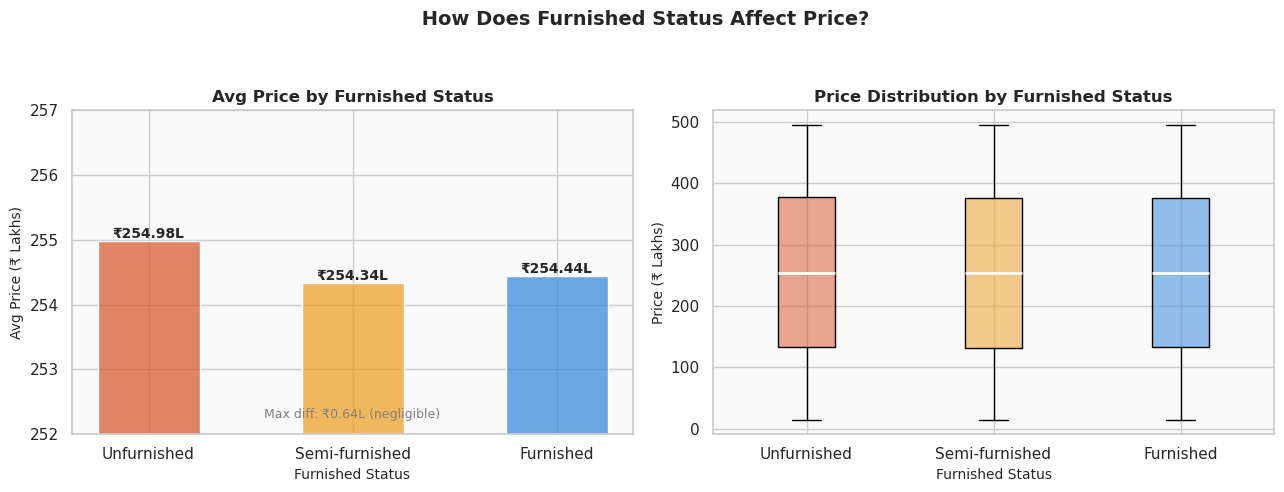

In [53]:
#Price by Furnished Status
furn_stats = df.groupby("Furnished_Status")["Price_in_Lakhs"].agg(["mean","median","std","count"])
furn_order = ["Unfurnished","Semi-furnished","Furnished"]
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
# Bar: mean price
axes[0].bar(furn_order,
            [furn_stats.loc[f,"mean"] for f in furn_order],
            color=[CORAL+"bb", AMBER+"bb", BLUE+"bb"], edgecolor="white", width=0.5)
axes[0].set_title("Avg Price by Furnished Status", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Furnished Status", fontsize=10)
axes[0].set_ylabel("Avg Price (₹ Lakhs)", fontsize=10)
axes[0].set_ylim(252, 257)
for i, f in enumerate(furn_order):
    axes[0].text(i, furn_stats.loc[f,"mean"] + 0.05,
                 f"₹{furn_stats.loc[f,'mean']:.2f}L", ha="center", fontsize=10, fontweight="bold")
axes[0].text(0.5, 0.05,
             f"Max diff: ₹{max(furn_stats['mean'])-min(furn_stats['mean']):.2f}L (negligible)",
             transform=axes[0].transAxes, ha="center", fontsize=9, color="gray")
 
# Box plot
furn_data14 = [df[df["Furnished_Status"]==f]["Price_in_Lakhs"].values for f in furn_order]
bp14 = axes[1].boxplot(furn_data14, patch_artist=True, labels=furn_order,
                        flierprops=dict(marker=".", markersize=1.5, alpha=0.2),
                        medianprops=dict(color="white", linewidth=2))
for patch, color in zip(bp14["boxes"], [CORAL+"88", AMBER+"88", BLUE+"88"]):
    patch.set_facecolor(color)
axes[1].set_title("Price Distribution by Furnished Status", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Furnished Status", fontsize=10)
axes[1].set_ylabel("Price (₹ Lakhs)", fontsize=10)
 
fig.suptitle(" How Does Furnished Status Affect Price?", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [54]:
print("\n Output — Price stats by Furnished Status:")
print(furn_stats[["mean","median","count"]].round(2).to_string())
print(f"\n📌 Insight: Difference between Furnished and Unfurnished = ₹{abs(furn_stats.loc['Furnished','mean']-furn_stats.loc['Unfurnished','mean']):.2f}L (<0.25%).")
print("   Statistically negligible. Furnished_Status → low feature importance.")
print("   Include it in the model but don't expect it to rank highly.")


 Output — Price stats by Furnished Status:
                    mean  median  count
Furnished_Status                       
Furnished         254.44  253.56  83218
Semi-furnished    254.34  253.81  83374
Unfurnished       254.98  254.19  83408

📌 Insight: Difference between Furnished and Unfurnished = ₹0.53L (<0.25%).
   Statistically negligible. Furnished_Status → low feature importance.
   Include it in the model but don't expect it to rank highly.


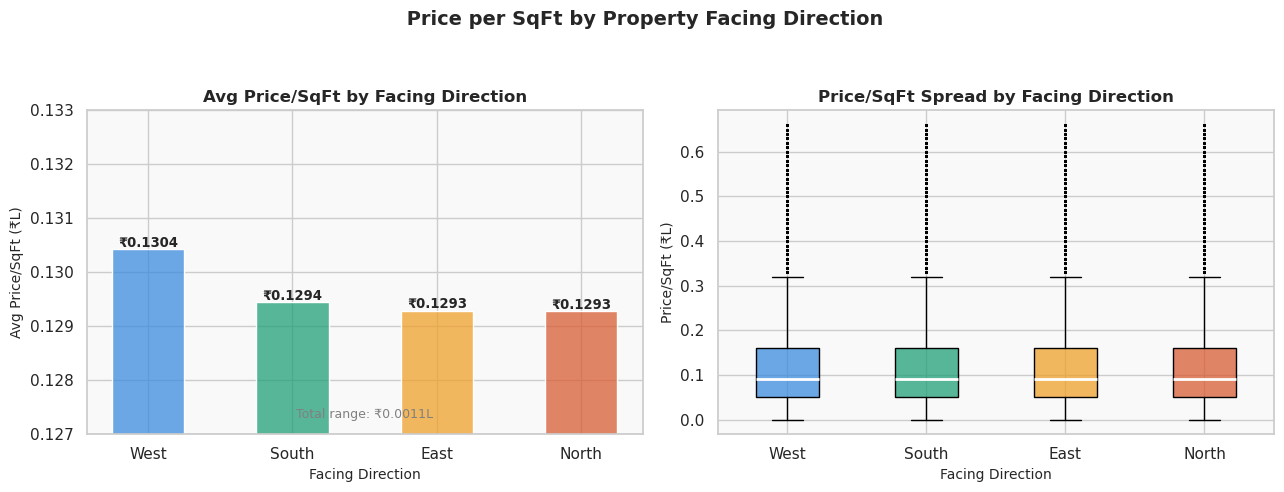

In [55]:
#Price per SqFt by Property Facing Direction
facing_stats = df.groupby("Facing")["Price_per_SqFt"].agg(["mean","median","std"])
facing_order = facing_stats["mean"].sort_values(ascending=False).index.tolist()
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
face_colors = [BLUE+"bb", TEAL+"bb", AMBER+"bb", CORAL+"bb"]
bars15 = axes[0].bar(facing_order,
                     [facing_stats.loc[f,"mean"] for f in facing_order],
                     color=face_colors, edgecolor="white", width=0.5)
axes[0].set_title("Avg Price/SqFt by Facing Direction", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Facing Direction", fontsize=10)
axes[0].set_ylabel("Avg Price/SqFt (₹L)", fontsize=10)
axes[0].set_ylim(0.127, 0.133)
for bar, f in zip(bars15, facing_order):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.00005,
                 f"₹{facing_stats.loc[f,'mean']:.4f}", ha="center", fontsize=9.5, fontweight="bold")
axes[0].text(0.5, 0.05,
             f"Total range: ₹{facing_stats['mean'].max()-facing_stats['mean'].min():.4f}L",
             transform=axes[0].transAxes, ha="center", fontsize=9, color="gray")
 
# Box per direction
facing_data = [df[df["Facing"]==f]["Price_per_SqFt"].values for f in facing_order]
bp15 = axes[1].boxplot(facing_data, patch_artist=True, labels=facing_order,
                        flierprops=dict(marker=".", markersize=1.5, alpha=0.2),
                        medianprops=dict(color="white", linewidth=2))
for patch, color in zip(bp15["boxes"], face_colors):
    patch.set_facecolor(color)
axes[1].set_title("Price/SqFt Spread by Facing Direction", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Facing Direction", fontsize=10)
axes[1].set_ylabel("Price/SqFt (₹L)", fontsize=10)
 
fig.suptitle(" Price per SqFt by Property Facing Direction", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [56]:
print("\n Output — Price/SqFt stats by Facing:")
print(facing_stats.round(4).to_string())
print(f"\n📌 Insight: West (highest) vs North (lowest): ₹{facing_stats['mean'].max()-facing_stats['mean'].min():.4f}L difference.")
print("   Completely negligible — facing has ZERO practical effect on price/sqft.")
print("   Include in model for completeness; expect rank near bottom in feature importance.")
 

 
print("\n" + "=" * 58)



 Output — Price/SqFt stats by Facing:
          mean  median     std
Facing                        
East    0.1293    0.09  0.1255
North   0.1293    0.09  0.1257
South   0.1294    0.09  0.1263
West    0.1304    0.09  0.1266

📌 Insight: West (highest) vs North (lowest): ₹0.0011L difference.
   Completely negligible — facing has ZERO practical effect on price/sqft.
   Include in model for completeness; expect rank near bottom in feature importance.



Investment / Amenities / Ownership Analysis

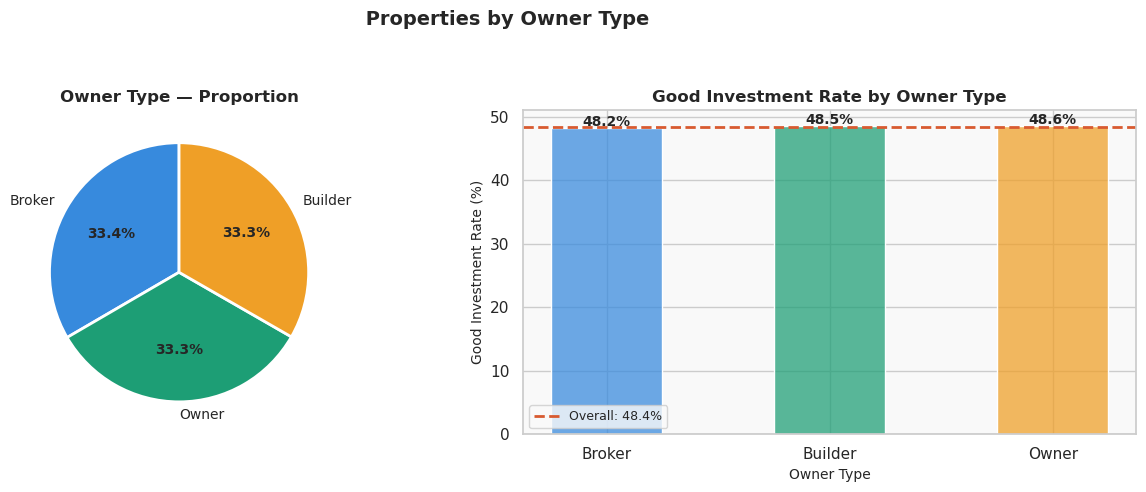

In [57]:
#Owner Type Distribution
owner_counts = df["Owner_Type"].value_counts()
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
# Pie
wedge_colors = [BLUE, TEAL, AMBER]
wedges, texts, autotexts = axes[0].pie(
    owner_counts.values,
    labels=owner_counts.index,
    autopct="%1.1f%%",
    colors=wedge_colors,
    startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=2),
    textprops=dict(fontsize=10)
)
for at in autotexts:
    at.set_fontsize(10); at.set_fontweight("bold")
axes[0].set_title("Owner Type — Proportion", fontsize=12, fontweight="bold")
 
# Good Investment rate by Owner Type
gi_owner = df.groupby("Owner_Type")["Good_Investment"].mean() * 100
axes[1].bar(gi_owner.index, gi_owner.values,
            color=[BLUE+"bb", TEAL+"bb", AMBER+"bb"], edgecolor="white", width=0.5)
axes[1].axhline(df["Good_Investment"].mean()*100, color=CORAL,
                linestyle="--", lw=2, label=f"Overall: {df['Good_Investment'].mean()*100:.1f}%")
axes[1].set_title("Good Investment Rate by Owner Type", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Owner Type", fontsize=10)
axes[1].set_ylabel("Good Investment Rate (%)", fontsize=10)
axes[1].legend(fontsize=9)
for i, (owner, val) in enumerate(gi_owner.items()):
    axes[1].text(i, val + 0.3, f"{val:.1f}%", ha="center", fontsize=10, fontweight="bold")
 
fig.suptitle(" Properties by Owner Type", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [58]:
print("\n Output:")
print(owner_counts.to_string())
print("\nGood Investment rate by Owner Type:")
print(gi_owner.round(2).to_string())
print(f"\n📌 Insight: Owner/Broker/Builder are each exactly ~33.3% — perfectly balanced.")
print("   Good Investment rates are near-identical across types (~48–49%).")
print("   Owner_Type has very low predictive power for investment classification.")



 Output:
Owner_Type
Broker     83479
Owner      83268
Builder    83253

Good Investment rate by Owner Type:
Owner_Type
Broker     48.21
Builder    48.55
Owner      48.56

📌 Insight: Owner/Broker/Builder are each exactly ~33.3% — perfectly balanced.
   Good Investment rates are near-identical across types (~48–49%).
   Owner_Type has very low predictive power for investment classification.


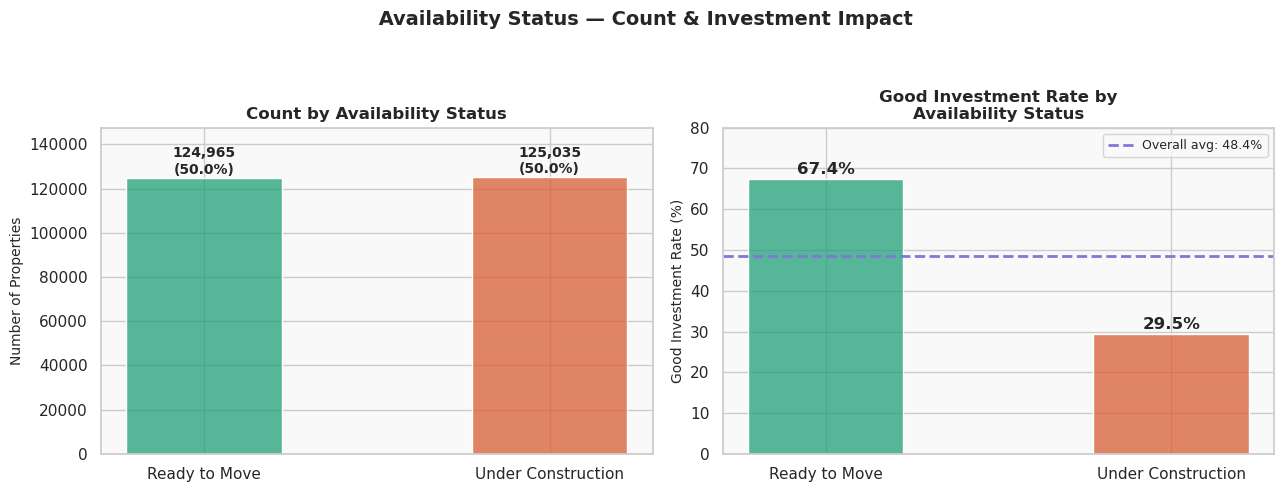

In [59]:
#Availability Status Distribution
avail_counts = df["Availability_Status"].value_counts()
gi_avail     = df.groupby("Availability_Status")["Good_Investment"].mean() * 100
labels17     = ["Ready to Move", "Under Construction"]
avail_keys   = ["Ready_to_Move", "Under_Construction"]
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
# Count bar
bars17 = axes[0].bar(labels17,
                     [avail_counts.get(k, 0) for k in avail_keys],
                     color=[TEAL+"bb", CORAL+"bb"], edgecolor="white", width=0.45)
axes[0].set_title("Count by Availability Status", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Number of Properties", fontsize=10)
axes[0].set_ylim(0, max(avail_counts.values) * 1.18)
for bar, key in zip(bars17, avail_keys):
    val = avail_counts.get(key, 0)
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f"{val:,}\n({val/len(df)*100:.1f}%)",
                 ha="center", va="bottom", fontsize=10, fontweight="bold")
 
# Good Investment rate comparison
bars17b = axes[1].bar(labels17,
                      [gi_avail.get(k, 0) for k in avail_keys],
                      color=[TEAL+"bb", CORAL+"bb"], edgecolor="white", width=0.45)
axes[1].axhline(df["Good_Investment"].mean()*100, color=PURPLE,
                linestyle="--", lw=2, label=f"Overall avg: {df['Good_Investment'].mean()*100:.1f}%")
axes[1].set_title("Good Investment Rate by\nAvailability Status", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Good Investment Rate (%)", fontsize=10)
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 80)
for bar, key in zip(bars17b, avail_keys):
    val = gi_avail.get(key, 0)
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.5,
                 f"{val:.1f}%", ha="center", va="bottom", fontsize=12, fontweight="bold")
 
fig.suptitle(" Availability Status — Count & Investment Impact",
             fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [60]:
print("\n Output:")
print(avail_counts.to_string())
print("\nGood Investment rate:")
print(gi_avail.round(2).to_string())
print(f"\n📌 Insight ⭐: Ready_to_Move properties have {gi_avail.get('Ready_to_Move',0):.1f}% Good Investment rate")
print(f"   vs Under_Construction {gi_avail.get('Under_Construction',0):.1f}%. A {gi_avail.get('Ready_to_Move',0)-gi_avail.get('Under_Construction',0):.1f}pp gap!")
print("   Availability_Status is one of the 5 classification rule factors — and one of")
print("   the strongest predictors of investment quality in this dataset.")


 Output:
Availability_Status
Under_Construction    125035
Ready_to_Move         124965

Good Investment rate:
Availability_Status
Ready_to_Move         67.43
Under_Construction    29.46

📌 Insight ⭐: Ready_to_Move properties have 67.4% Good Investment rate
   vs Under_Construction 29.5%. A 38.0pp gap!
   Availability_Status is one of the 5 classification rule factors — and one of
   the strongest predictors of investment quality in this dataset.


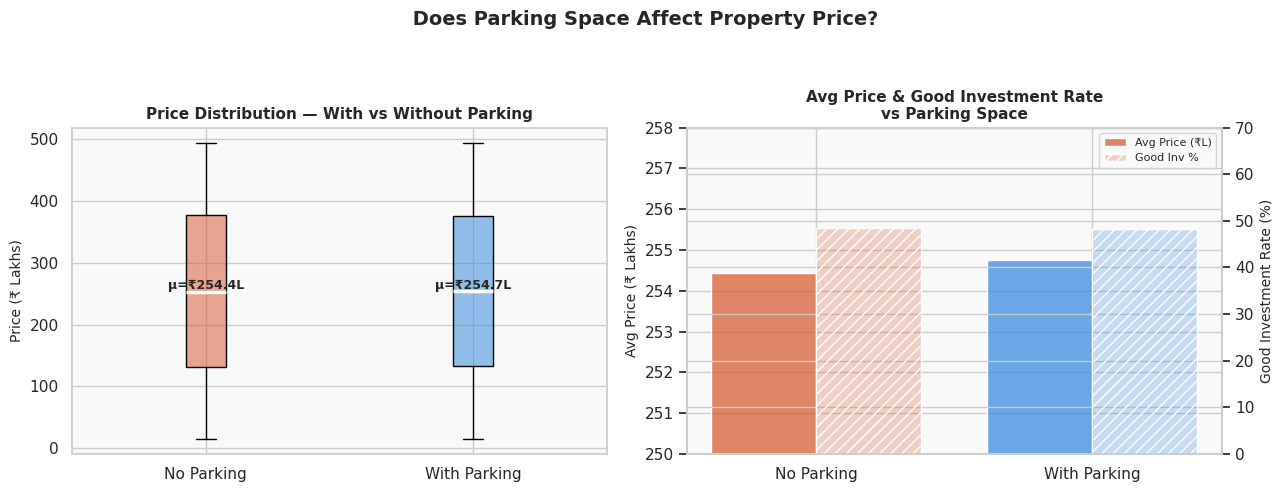

In [61]:
#Parking Space vs Property Price

park_stats   = df.groupby("Parking_Space")["Price_in_Lakhs"].agg(["mean","median","std","count"])
park_gi      = df.groupby("Parking_Space")["Good_Investment"].mean() * 100
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
# Box plot
park_data = [df[df["Parking_Space"]=="No"]["Price_in_Lakhs"].values,
             df[df["Parking_Space"]=="Yes"]["Price_in_Lakhs"].values]
bp18 = axes[0].boxplot(park_data, patch_artist=True,
                        labels=["No Parking", "With Parking"],
                        flierprops=dict(marker=".", markersize=1.5, alpha=0.2),
                        medianprops=dict(color="white", linewidth=2.5))
for patch, color in zip(bp18["boxes"], [CORAL+"88", BLUE+"88"]):
    patch.set_facecolor(color)
axes[0].set_title("Price Distribution — With vs Without Parking", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Price (₹ Lakhs)", fontsize=10)
for i, key in enumerate(["No", "Yes"]):
    axes[0].text(i+1, park_stats.loc[key,"mean"] + 3,
                 f"μ=₹{park_stats.loc[key,'mean']:.1f}L",
                 ha="center", fontsize=9, fontweight="bold")
 
# Mean + Good Investment side by side
x18    = np.arange(2)
width  = 0.38
ax18r  = axes[1].twinx()
bars18a = axes[1].bar(x18 - width/2,
                       [park_stats.loc[k,"mean"] for k in ["No","Yes"]],
                       width=width, color=[CORAL+"bb", BLUE+"bb"],
                       edgecolor="white", label="Avg Price (₹L)")
bars18b = ax18r.bar(x18 + width/2,
                     [park_gi["No"], park_gi["Yes"]],
                     width=width, color=[CORAL+"44", BLUE+"44"],
                     edgecolor="white", hatch="///", label="Good Inv %")
axes[1].set_title("Avg Price & Good Investment Rate\nvs Parking Space", fontsize=11, fontweight="bold")
axes[1].set_xticks(x18); axes[1].set_xticklabels(["No Parking", "With Parking"])
axes[1].set_ylabel("Avg Price (₹ Lakhs)", fontsize=10)
ax18r.set_ylabel("Good Investment Rate (%)", fontsize=10)
axes[1].set_ylim(250, 258); ax18r.set_ylim(0, 70)
h1, l1 = axes[1].get_legend_handles_labels()
h2, l2 = ax18r.get_legend_handles_labels()
axes[1].legend(h1+h2, l1+l2, fontsize=8)
 
fig.suptitle(" Does Parking Space Affect Property Price?", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [62]:
print("\n Output — Price stats by Parking Space:")
print(park_stats[["mean","median","count"]].round(2).to_string())
print(f"\n📌 Insight: Price diff = ₹{park_stats.loc['Yes','mean']-park_stats.loc['No','mean']:.2f}L — essentially zero.")
print("   Parking space does NOT affect property price in this dataset.")
print("   Low feature importance expected in both classification and regression models.")


 Output — Price stats by Parking Space:
                 mean  median   count
Parking_Space                        
No             254.43  253.37  125456
Yes            254.74  254.36  124544

📌 Insight: Price diff = ₹0.32L — essentially zero.
   Parking space does NOT affect property price in this dataset.
   Low feature importance expected in both classification and regression models.


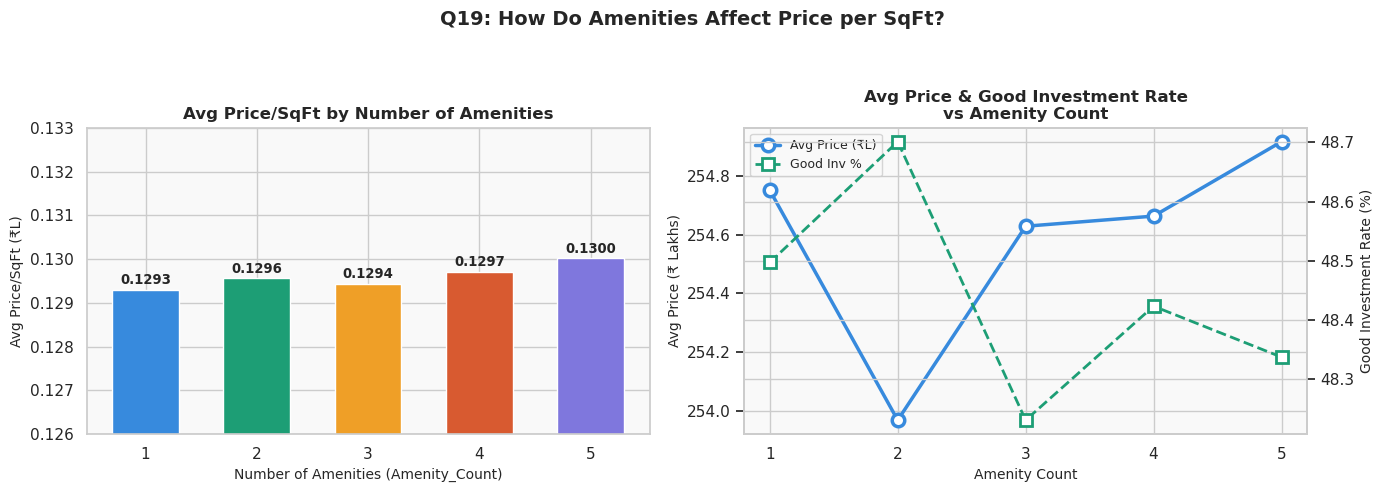

In [63]:
 #Amenities vs Price per SqFt
amenity_psqft = df.groupby("Amenity_Count")["Price_per_SqFt"].agg(["mean","std"])
amenity_price = df.groupby("Amenity_Count")["Price_in_Lakhs"].mean()
amenity_gi    = df.groupby("Amenity_Count")["Good_Investment"].mean() * 100
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Bar: price per sqft by amenity count
bar_colors19 = [BLUE, TEAL, AMBER, CORAL, PURPLE]
bars19 = axes[0].bar(amenity_psqft.index, amenity_psqft["mean"],
                     color=bar_colors19, edgecolor="white", width=0.6)
axes[0].set_title("Avg Price/SqFt by Number of Amenities", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Number of Amenities (Amenity_Count)", fontsize=10)
axes[0].set_ylabel("Avg Price/SqFt (₹L)", fontsize=10)
axes[0].set_xticks(amenity_psqft.index)
axes[0].set_ylim(0.126, 0.133)
for bar, val in zip(bars19, amenity_psqft["mean"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.00005,
                 f"{val:.4f}", ha="center", va="bottom", fontsize=9.5, fontweight="bold")
 
# Line: Good Investment rate vs amenity count
ax19r = axes[1].twinx()
line1, = axes[1].plot(amenity_price.index, amenity_price.values, "o-",
                       color=BLUE, lw=2.5, markersize=9,
                       markerfacecolor="white", markeredgewidth=2.5, label="Avg Price (₹L)")
line2, = ax19r.plot(amenity_gi.index, amenity_gi.values, "s--",
                     color=TEAL, lw=2, markersize=8,
                     markerfacecolor="white", markeredgewidth=2, label="Good Inv %")
axes[1].set_title("Avg Price & Good Investment Rate\nvs Amenity Count", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Amenity Count", fontsize=10)
axes[1].set_ylabel("Avg Price (₹ Lakhs)", fontsize=10)
ax19r.set_ylabel("Good Investment Rate (%)", fontsize=10)
axes[1].set_xticks(amenity_price.index)
axes[1].legend(handles=[line1, line2], fontsize=9, loc="upper left")
 
fig.suptitle("Q19: How Do Amenities Affect Price per SqFt?", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [64]:
print("\n Output — Price/SqFt & Good Investment by Amenity Count:")
result19 = pd.DataFrame({"Avg_Price_per_SqFt": amenity_psqft["mean"],
                          "Avg_Price": amenity_price,
                          "Good_Investment_Rate%": amenity_gi})
print(result19.round(4).to_string())
print(f"\n📌 Insight: Price/SqFt range across amenity counts = ₹{amenity_psqft['mean'].max()-amenity_psqft['mean'].min():.4f}L — negligible.")
print("   Amenity count has almost zero effect on per-sqft pricing.")
print("   Amenity_Score is more useful as an ordinal signal for the classification model.")


 Output — Price/SqFt & Good Investment by Amenity Count:
               Avg_Price_per_SqFt  Avg_Price  Good_Investment_Rate%
Amenity_Count                                                      
1                          0.1293   254.7508                48.4972
2                          0.1296   253.9671                48.7010
3                          0.1294   254.6282                48.2311
4                          0.1297   254.6627                48.4234
5                          0.1300   254.9165                48.3375

📌 Insight: Price/SqFt range across amenity counts = ₹0.0007L — negligible.
   Amenity count has almost zero effect on per-sqft pricing.
   Amenity_Score is more useful as an ordinal signal for the classification model.


<ipython-input-65-a16f925289a5>:52: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from current font.
  plt.tight_layout(rect=[0, 0, 1, 0.93])
/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


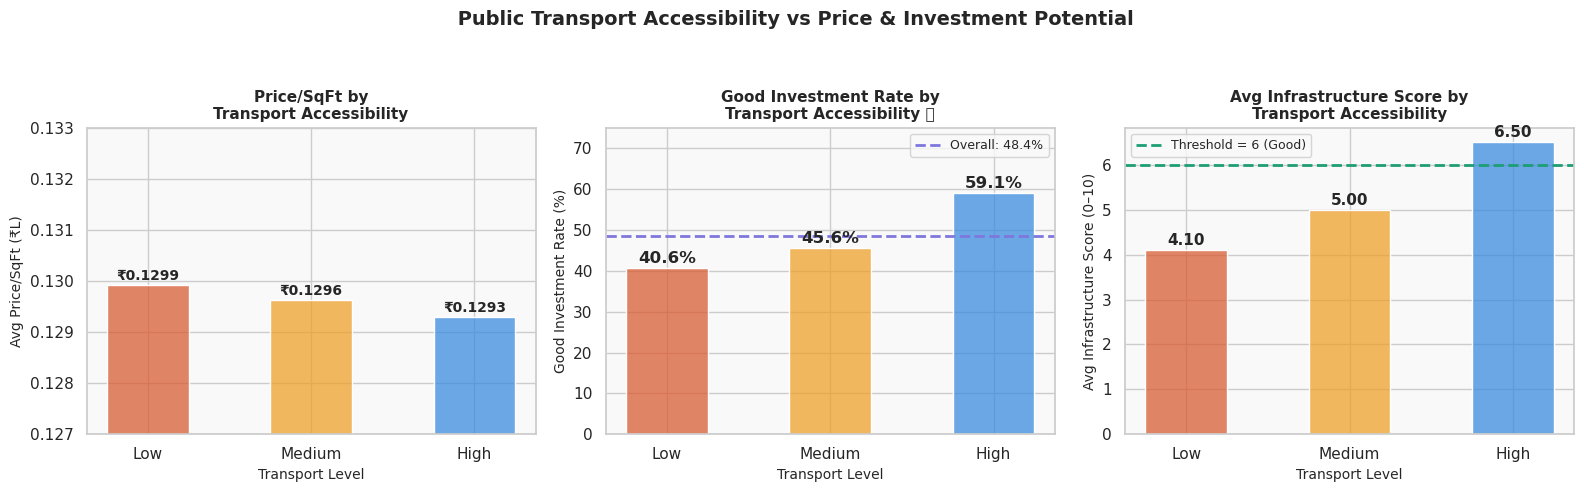

In [65]:
#Public Transport vs Price/SqFt & Good Investment Rate
transport_order = ["Low", "Medium", "High"]
transport_psqft = df.groupby("Public_Transport_Accessibility")["Price_per_SqFt"].mean()
transport_price = df.groupby("Public_Transport_Accessibility")["Price_in_Lakhs"].mean()
transport_gi    = df.groupby("Public_Transport_Accessibility")["Good_Investment"].mean() * 100
transport_infra = df.groupby("Public_Transport_Accessibility")["Infrastructure_Score"].mean()
 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
 
# Bar: Price/SqFt
bars20a = axes[0].bar(transport_order,
                      [transport_psqft[o] for o in transport_order],
                      color=[CORAL+"bb", AMBER+"bb", BLUE+"bb"], edgecolor="white", width=0.5)
axes[0].set_title("Price/SqFt by\nTransport Accessibility", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Transport Level", fontsize=10)
axes[0].set_ylabel("Avg Price/SqFt (₹L)", fontsize=10)
axes[0].set_ylim(0.127, 0.133)
for bar, o in zip(bars20a, transport_order):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.00005,
                 f"₹{transport_psqft[o]:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
 
# Bar: Good Investment Rate
bars20b = axes[1].bar(transport_order,
                      [transport_gi[o] for o in transport_order],
                      color=[CORAL+"bb", AMBER+"bb", BLUE+"bb"], edgecolor="white", width=0.5)
axes[1].axhline(df["Good_Investment"].mean()*100, color=PURPLE,
                linestyle="--", lw=2, label=f"Overall: {df['Good_Investment'].mean()*100:.1f}%")
axes[1].set_title("Good Investment Rate by\nTransport Accessibility ⭐", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Transport Level", fontsize=10)
axes[1].set_ylabel("Good Investment Rate (%)", fontsize=10)
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 75)
for bar, o in zip(bars20b, transport_order):
    axes[1].text(bar.get_x() + bar.get_width()/2, transport_gi[o] + 0.5,
                 f"{transport_gi[o]:.1f}%", ha="center", va="bottom", fontsize=12, fontweight="bold")
 
# Bar: Avg Infrastructure Score
bars20c = axes[2].bar(transport_order,
                      [transport_infra[o] for o in transport_order],
                      color=[CORAL+"bb", AMBER+"bb", BLUE+"bb"], edgecolor="white", width=0.5)
axes[2].axhline(6, color=TEAL, linestyle="--", lw=2, label="Threshold = 6 (Good)")
axes[2].set_title("Avg Infrastructure Score by\nTransport Accessibility", fontsize=11, fontweight="bold")
axes[2].set_xlabel("Transport Level", fontsize=10)
axes[2].set_ylabel("Avg Infrastructure Score (0–10)", fontsize=10)
axes[2].legend(fontsize=9)
for bar, o in zip(bars20c, transport_order):
    axes[2].text(bar.get_x() + bar.get_width()/2, transport_infra[o] + 0.05,
                 f"{transport_infra[o]:.2f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
 
fig.suptitle(" Public Transport Accessibility vs Price & Investment Potential",
             fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [66]:
print("\nQ20 Output:")
result20 = pd.DataFrame({
    "Avg_Price_per_SqFt": [transport_psqft[o] for o in transport_order],
    "Avg_Price_Lakhs":    [transport_price[o]  for o in transport_order],
    "Good_Inv_Rate%":     [transport_gi[o]     for o in transport_order],
    "Avg_Infra_Score":    [transport_infra[o]  for o in transport_order],
}, index=transport_order)
print(result20.round(4).to_string())
print(f"\n📌 Insight ⭐ (Key finding of the entire EDA):")
print(f"   • Price/SqFt is FLAT across transport levels (range < ₹0.001L) — transport")
print(f"     does NOT affect raw pricing in this dataset.")
print(f"   • BUT Good Investment rate: High={transport_gi['High']:.1f}%  Medium={transport_gi['Medium']:.1f}%  Low={transport_gi['Low']:.1f}%")
print(f"     → A {transport_gi['High']-transport_gi['Low']:.1f}pp gap between High and Low transport!")
print(f"   • Mechanism: High transport → higher Infrastructure_Score → more likely to cross")
print(f"     the score≥6 threshold → triggers +1 in invest_score → drives Good_Investment=1.")
print(f"   This is the most actionable insight: location near good transport is the single")
print(f"   most powerful non-price indicator of investment quality.")



Q20 Output:
        Avg_Price_per_SqFt  Avg_Price_Lakhs  Good_Inv_Rate%  Avg_Infra_Score
Low                 0.1299         254.8631         40.5658           4.1012
Medium              0.1296         253.9715         45.6197           4.9951
High                0.1293         254.9183         59.0658           6.5012

📌 Insight ⭐ (Key finding of the entire EDA):
   • Price/SqFt is FLAT across transport levels (range < ₹0.001L) — transport
     does NOT affect raw pricing in this dataset.
   • BUT Good Investment rate: High=59.1%  Medium=45.6%  Low=40.6%
     → A 18.5pp gap between High and Low transport!
   • Mechanism: High transport → higher Infrastructure_Score → more likely to cross
     the score≥6 threshold → triggers +1 in invest_score → drives Good_Investment=1.
   This is the most actionable insight: location near good transport is the single
   most powerful non-price indicator of investment quality.


In [67]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

In [68]:


TARGET_REG = "Future_Price_5yr"
TARGET_CLS = "Good_Investment"

drop_cols = ["ID", "Locality", "Amenities", "City_Growth_Rate",
             "Price_per_SqFt", "Transport_Score"]
df_model = df.drop(columns=[c for c in drop_cols if c in df.columns])
 
print(f"\n Dropped {[c for c in drop_cols if c in df.columns]}")
print(f"     Shape after drop: {df_model.shape}")

y_reg = df_model[TARGET_REG].copy()
y_cls = df_model[TARGET_CLS].copy()
X     = df_model.copy()

#Binary encoding 
binary_cols = ["Parking_Space", "Security"]
for col in binary_cols:
    df_model[col] = (df_model[col] == "Yes").astype(int)
 
print(f"\n Binary encoded: {binary_cols}")
print(df_model[binary_cols].value_counts().to_string())


 Dropped ['ID', 'Locality', 'Amenities', 'City_Growth_Rate', 'Price_per_SqFt', 'Transport_Score']
     Shape after drop: (250000, 39)

 Binary encoded: ['Parking_Space', 'Security']
Parking_Space  Security
0              0           62762
               1           62694
1              1           62539
               0           62005


In [69]:
furnished_map   = {"Unfurnished": 0, "Semi-furnished": 1, "Furnished": 2}
transport_map   = {"Low": 0, "Medium": 1, "High": 2}
age_group_map   = {"Old": 0, "Moderate": 1, "New": 2}
bhk_cat_map     = {"Small": 0, "Medium": 1, "Large": 2}
price_cat_map   = {"Budget": 0, "Mid-Range": 1, "Premium": 2, "Luxury": 3}
 
df_model["Furnished_Status"]              = df_model["Furnished_Status"].map(furnished_map)
df_model["Public_Transport_Accessibility"]= df_model["Public_Transport_Accessibility"].map(transport_map)
df_model["Property_Age_Group"]            = df_model["Property_Age_Group"].map(age_group_map)
df_model["BHK_Category"]                 = df_model["BHK_Category"].map(bhk_cat_map)
df_model["Price_Category"]               = df_model["Price_Category"].map(price_cat_map)
 
print(f"\n Ordinal encoded 5 columns")
print("     Furnished_Status    :", df_model["Furnished_Status"].value_counts().to_dict())
print("     Public_Transport    :", df_model["Public_Transport_Accessibility"].value_counts().to_dict())


 Ordinal encoded 5 columns
     Furnished_Status    : {0: 83408, 1: 83374, 2: 83218}
     Public_Transport    : {2: 83705, 0: 83287, 1: 83008}


In [70]:
for col in ["State", "City"]:
    mapping = df_model.groupby(col)["Price_in_Lakhs"].mean()
    df_model[f"{col}_Encoded"] = df_model[col].map(mapping).round(2)
 
df_model.drop(columns=["State", "City"], inplace=True)
 
print(f"\n Target encoded: State → State_Encoded, City → City_Encoded")
print(f"     State_Encoded range: {df_model['State_Encoded'].min():.2f} – {df_model['State_Encoded'].max():.2f}")
print(f"     City_Encoded range : {df_model['City_Encoded'].min():.2f} – {df_model['City_Encoded'].max():.2f}")


 Target encoded: State → State_Encoded, City → City_Encoded
     State_Encoded range: 252.53 – 257.41
     City_Encoded range : 250.79 – 258.44


In [71]:
ohe_cols = ["Property_Type", "Facing", "Owner_Type", "Availability_Status"]
df_model = pd.get_dummies(df_model, columns=ohe_cols, drop_first=True, dtype=int)
 
new_ohe = [c for c in df_model.columns if any(
    c.startswith(p) for p in ["Property_Type", "Facing", "Owner_Type", "Availability"]
)]
print(f"\n One-hot encoded {ohe_cols}")
print(f"     New OHE columns: {new_ohe}")


 One-hot encoded ['Property_Type', 'Facing', 'Owner_Type', 'Availability_Status']
     New OHE columns: ['Property_Type_Independent House', 'Property_Type_Villa', 'Facing_North', 'Facing_South', 'Facing_West', 'Owner_Type_Builder', 'Owner_Type_Owner', 'Availability_Status_Under_Construction']


In [72]:
y_reg = df_model["Future_Price_5yr"] 
y_cls = df_model["Good_Investment"]  
X = df_model.copy()

# Remove target columns from features
X = X.drop(columns=["Future_Price_5yr", "Good_Investment"])  

# Stratified split on classification target
X_train, X_test, \
y_cls_train, y_cls_test, \
y_reg_train, y_reg_test = train_test_split(
    X, y_cls, y_reg,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)

print(f"\n[4F] Train/test split (80/20, stratified on Good_Investment):")
print(f"     X_train : {X_train.shape}   X_test : {X_test.shape}")
print(f"     y_cls_train balance : {y_cls_train.mean()*100:.1f}% Good Investment")
print(f"     y_cls_test  balance : {y_cls_test.mean()*100:.1f}% Good Investment")
print(f"     y_reg_train range   : ₹{y_reg_train.min():.1f}L – ₹{y_reg_train.max():.1f}L")


[4F] Train/test split (80/20, stratified on Good_Investment):
     X_train : (200000, 41)   X_test : (50000, 41)
     y_cls_train balance : 48.4% Good Investment
     y_cls_test  balance : 48.4% Good Investment
     y_reg_train range   : ₹20.9L – ₹872.2L


In [73]:



if "price_per_sqrft_computed" in X_train.columns:
    X_train.rename(columns={"price_per_sqrft_computed": "Price_per_SqFt_Computed"}, inplace=True)
    X_test.rename(columns={"price_per_sqrft_computed": "Price_per_SqFt_Computed"}, inplace=True)


standard_cols = [c for c in [
    "Price_in_Lakhs", "Size_in_SqFt", "Price_per_SqFt_Computed",
    "Floor_No", "Total_Floors", "Year_Built", "Age_of_Property",
    "Nearby_Schools", "Nearby_Hospitals",
    "City_Encoded", "State_Encoded"
] if c in X_train.columns]

minmax_cols = [c for c in [
    "Infrastructure_Score", "School_Density_Score", "Hospital_Density_Score",
    "Amenity_Score", "Amenity_Count", "Floor_Ratio"
] if c in X_train.columns]


# Replace infinity
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill missing values using TRAIN stats
X_train[standard_cols + minmax_cols] = X_train[standard_cols + minmax_cols].fillna(
    X_train[standard_cols + minmax_cols].median()
)

X_test[standard_cols + minmax_cols] = X_test[standard_cols + minmax_cols].fillna(
    X_train[standard_cols + minmax_cols].median()
)


scaler_std = StandardScaler()
scaler_mm  = MinMaxScaler()

# Standard Scaling
X_train[standard_cols] = scaler_std.fit_transform(X_train[standard_cols])
X_test[standard_cols]  = scaler_std.transform(X_test[standard_cols])

# MinMax Scaling
X_train[minmax_cols] = scaler_mm.fit_transform(X_train[minmax_cols])
X_test[minmax_cols]  = scaler_mm.transform(X_test[minmax_cols])


assert np.isfinite(X_train.select_dtypes(include=[np.number])).all().all(), "Still contains invalid values!"

# -----------------------------
# 6. OUTPUT
# -----------------------------
print(f"\n✅ StandardScaler applied to {len(standard_cols)} columns")
print(f"✅ MinMaxScaler applied to {len(minmax_cols)} columns")
print("✅ Fitted on X_train ONLY — transformed X_test (no data leakage)")


✅ StandardScaler applied to 11 columns
✅ MinMaxScaler applied to 6 columns
✅ Fitted on X_train ONLY — transformed X_test (no data leakage)


In [74]:
print("Columns with non-numeric dtype in X_train:")
bad_cols = X_train.select_dtypes(include=["object", "category", "string"]).columns.tolist()
 
if bad_cols:
    print(f"  Found {len(bad_cols)} bad column(s): {bad_cols}")
else:
    print("  None found. ✅")

if bad_cols:
    X_train = X_train.drop(columns=bad_cols)
    X_test  = X_test.drop(columns=bad_cols)
    print(f"\n  Dropped from X_train and X_test: {bad_cols}")
 

for col in X_train.columns:
    if X_train[col].dtype.name == "category":
        X_train[col] = X_train[col].astype(int)
        X_test[col]  = X_test[col].astype(int)
        print(f"  Converted category → int: {col}")
 

nan_count = X_train.isnull().sum().sum()
if nan_count > 0:
    print(f"\n  Found {nan_count} NaN values — filling with 0")
    X_train = X_train.fillna(0)
    X_test  = X_test.fillna(0)

print(f"\n  X_train shape : {X_train.shape}")
print(f"  X_test  shape : {X_test.shape}")
print(f"  Remaining dtypes:\n{X_train.dtypes.value_counts().to_string()}")
print(f"\n  ✅ X_train and X_test are clean — ready for model training.")

Columns with non-numeric dtype in X_train:
  Found 4 bad column(s): ['Property_Age_Group', 'BHK_Category', 'Price_Category', 'Size_Bin']

  Dropped from X_train and X_test: ['Property_Age_Group', 'BHK_Category', 'Price_Category', 'Size_Bin']

  X_train shape : (200000, 37)
  X_test  shape : (50000, 37)
  Remaining dtypes:
float64    17
int32      17
int64       3

  ✅ X_train and X_test are clean — ready for model training.


In [75]:
from sklearn.linear_model  import LogisticRegression, LinearRegression
from sklearn.ensemble       import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics        import (accuracy_score, f1_score, confusion_matrix,
                                    classification_report,
                                    mean_squared_error, mean_absolute_error, r2_score)
from xgboost import XGBClassifier, XGBRegressor

In [76]:
cls_models = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42, n_jobs=-1),
    "Random Forest":       RandomForestClassifier(n_estimators=200, max_depth=12,
                                                  random_state=42, n_jobs=-1),
    "XGBoost":             XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                         use_label_encoder=False, eval_metric="logloss",
                                         random_state=42, n_jobs=-1),
}
 
cls_results = {}
for name, model in cls_models.items():
    print(f"\n  Training {name}...")
    model.fit(X_train, y_cls_train)
    y_pred = model.predict(X_test)
 
    acc = accuracy_score(y_cls_test, y_pred)
    f1  = f1_score(y_cls_test, y_pred, average="weighted")
    cm  = confusion_matrix(y_cls_test, y_pred)
 
    cls_results[name] = {
        "model": model, "y_pred": y_pred,
        "accuracy": acc, "f1": f1, "cm": cm
    }
    print(f"    Accuracy : {acc*100:.2f}%")
    print(f"    F1 Score : {f1:.4f}")
    print(f"    Confusion Matrix:\n{cm}")
 
# ── Best classification model
best_cls_name = max(cls_results, key=lambda k: cls_results[k]["f1"])
best_cls      = cls_results[best_cls_name]["model"]
print(f"\n  ✅ Best classifier: {best_cls_name} (F1={cls_results[best_cls_name]['f1']:.4f})")
 


  Training Logistic Regression...
    Accuracy : 87.04%
    F1 Score : 0.8704
    Confusion Matrix:
[[22581  3200]
 [ 3280 20939]]

  Training Random Forest...
    Accuracy : 99.58%
    F1 Score : 0.9958
    Confusion Matrix:
[[25687    94]
 [  116 24103]]

  Training XGBoost...


/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [22:24:27] WARNING: /home/runner/work/pyodide-recipes/pyodide-recipes/packages/xgboost/build/xgboost-2.1.4/cpp_src/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


    Accuracy : 99.81%
    F1 Score : 0.9981
    Confusion Matrix:
[[25722    59]
 [   36 24183]]

  ✅ Best classifier: XGBoost (F1=0.9981)


<Figure size 640x480 with 0 Axes>

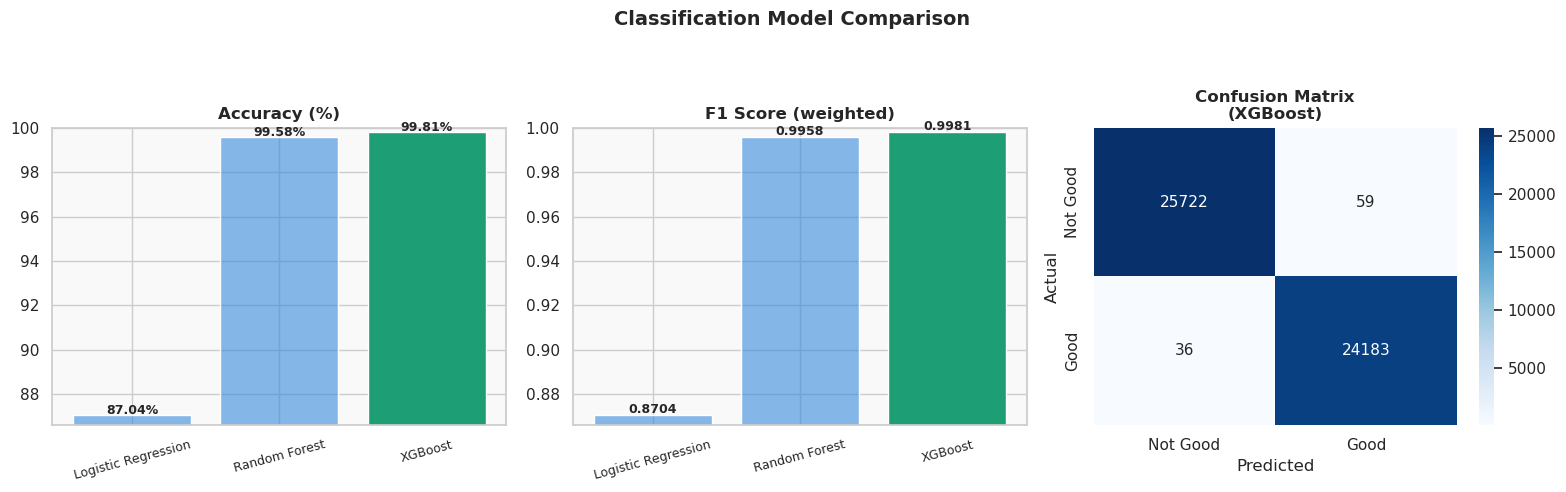

In [77]:
import os
os.makedirs("plots", exist_ok=True)

plt.savefig("plots/classification_comparison.png", dpi=150, bbox_inches="tight")
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Classification Model Comparison", fontsize=14, fontweight="bold")
 
names = list(cls_results.keys())
accs  = [cls_results[n]["accuracy"]*100 for n in names]
f1s   = [cls_results[n]["f1"] for n in names]
cols  = [TEAL if n == best_cls_name else BLUE+"99" for n in names]
 
axes[0].bar(names, accs, color=cols, edgecolor="white")
axes[0].set_title("Accuracy (%)", fontweight="bold")
axes[0].set_ylim(min(accs)*0.995, 100)
axes[0].tick_params(axis="x", rotation=15, labelsize=9)
for i, v in enumerate(accs):
    axes[0].text(i, v + 0.05, f"{v:.2f}%", ha="center", fontsize=9, fontweight="bold")
 
axes[1].bar(names, f1s, color=cols, edgecolor="white")
axes[1].set_title("F1 Score (weighted)", fontweight="bold")
axes[1].set_ylim(min(f1s)*0.995, 1.0)
axes[1].tick_params(axis="x", rotation=15, labelsize=9)
for i, v in enumerate(f1s):
    axes[1].text(i, v + 0.001, f"{v:.4f}", ha="center", fontsize=9, fontweight="bold")
 
# Confusion matrix of best model
cm_best = cls_results[best_cls_name]["cm"]
sns.heatmap(cm_best, annot=True, fmt="d", cmap="Blues", ax=axes[2],
            xticklabels=["Not Good", "Good"], yticklabels=["Not Good", "Good"],
            annot_kws={"size": 11})
axes[2].set_title(f"Confusion Matrix\n({best_cls_name})", fontweight="bold")
axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("Actual")
 
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("plots/classification_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [78]:
print(f"\n  Classification Report — {best_cls_name}:")
print(classification_report(y_cls_test, cls_results[best_cls_name]["y_pred"],
                              target_names=["Not Good Investment", "Good Investment"]))


  Classification Report — XGBoost:
                     precision    recall  f1-score   support

Not Good Investment       1.00      1.00      1.00     25781
    Good Investment       1.00      1.00      1.00     24219

           accuracy                           1.00     50000
          macro avg       1.00      1.00      1.00     50000
       weighted avg       1.00      1.00      1.00     50000



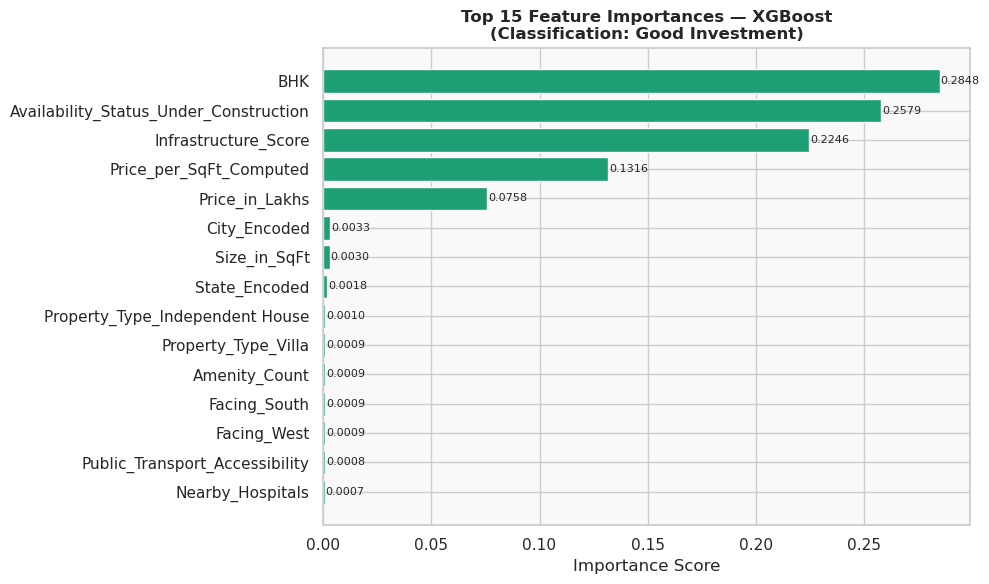

  Saved → plots/cls_feature_importance.png

  Top 5 features for Good Investment prediction:
    BHK                                 0.2848
    Availability_Status_Under_Construction 0.2579
    Infrastructure_Score                0.2246
    Price_per_SqFt_Computed             0.1316
    Price_in_Lakhs                      0.0758


In [79]:

if hasattr(best_cls, "feature_importances_"):
    fi_cls = pd.Series(best_cls.feature_importances_, index=X_train.columns)
    top15  = fi_cls.sort_values(ascending=False).head(15)
 
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top15.index[::-1], top15.values[::-1], color=TEAL, edgecolor="white")
    ax.set_title(f"Top 15 Feature Importances — {best_cls_name}\n(Classification: Good Investment)",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Importance Score")
    for i, val in enumerate(top15.values[::-1]):
        ax.text(val + 0.0005, i, f"{val:.4f}", va="center", fontsize=8)
    plt.tight_layout()
    plt.savefig("plots/cls_feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  Saved → plots/cls_feature_importance.png")
    print(f"\n  Top 5 features for Good Investment prediction:")
    for feat, imp in top15.head(5).items():
        print(f"    {feat:<35} {imp:.4f}")

In [80]:
## PART B : REGRESSION — Predict Future_Price_5yr

reg_models = {
    "Linear Regression": LinearRegression(n_jobs=-1),
    "Random Forest":     RandomForestRegressor(n_estimators=200, max_depth=12,
                                                random_state=42, n_jobs=-1),
    "XGBoost":           XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1,
                                      random_state=42, n_jobs=-1),
}
 
reg_results = {}
for name, model in reg_models.items():
    print(f"\n  Training {name}...")
    model.fit(X_train, y_reg_train)
    y_pred = model.predict(X_test)
 
    rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred))
    mae  = mean_absolute_error(y_reg_test, y_pred)
    r2   = r2_score(y_reg_test, y_pred)
 
    reg_results[name] = {
        "model": model, "y_pred": y_pred,
        "rmse": rmse, "mae": mae, "r2": r2
    }
    print(f"    RMSE : ₹{rmse:.2f}L")
    print(f"    MAE  : ₹{mae:.2f}L")
    print(f"    R²   : {r2:.4f}")
 
# ── Best regression model (lowest RMSE)
best_reg_name = min(reg_results, key=lambda k: reg_results[k]["rmse"])
best_reg      = reg_results[best_reg_name]["model"]
print(f"\n   Best regressor: {best_reg_name} (RMSE=₹{reg_results[best_reg_name]['rmse']:.2f}L)")


  Training Linear Regression...
    RMSE : ₹18.03L
    MAE  : ₹9.73L
    R²   : 0.9927

  Training Random Forest...
    RMSE : ₹4.48L
    MAE  : ₹1.76L
    R²   : 0.9995

  Training XGBoost...
    RMSE : ₹1.01L
    MAE  : ₹0.81L
    R²   : 1.0000

   Best regressor: XGBoost (RMSE=₹1.01L)


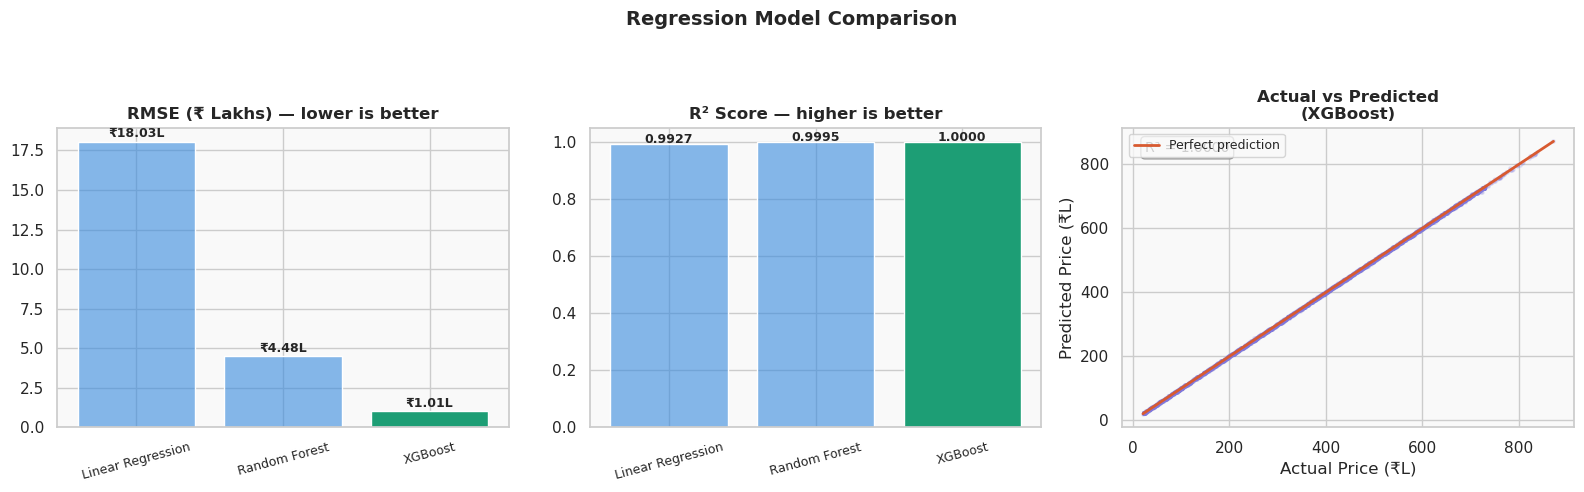

In [81]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Regression Model Comparison", fontsize=14, fontweight="bold")
 
names_r  = list(reg_results.keys())
rmses    = [reg_results[n]["rmse"] for n in names_r]
r2s      = [reg_results[n]["r2"]   for n in names_r]
cols_r   = [TEAL if n == best_reg_name else BLUE+"99" for n in names_r]
 
axes[0].bar(names_r, rmses, color=cols_r, edgecolor="white")
axes[0].set_title("RMSE (₹ Lakhs) — lower is better", fontweight="bold")
axes[0].tick_params(axis="x", rotation=15, labelsize=9)
for i, v in enumerate(rmses):
    axes[0].text(i, v + 0.3, f"₹{v:.2f}L", ha="center", fontsize=9, fontweight="bold")
 
axes[1].bar(names_r, r2s, color=cols_r, edgecolor="white")
axes[1].set_title("R² Score — higher is better", fontweight="bold")
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis="x", rotation=15, labelsize=9)
for i, v in enumerate(r2s):
    axes[1].text(i, v + 0.005, f"{v:.4f}", ha="center", fontsize=9, fontweight="bold")
 
# Actual vs Predicted scatter for best model
y_pred_best = reg_results[best_reg_name]["y_pred"]
sample_idx  = np.random.choice(len(y_reg_test), min(3000, len(y_reg_test)), replace=False)
axes[2].scatter(y_reg_test.values[sample_idx], y_pred_best[sample_idx],
                alpha=0.15, s=6, color=PURPLE)
mn = min(y_reg_test.min(), y_pred_best.min())
mx = max(y_reg_test.max(), y_pred_best.max())
axes[2].plot([mn, mx], [mn, mx], color=CORAL, lw=2, label="Perfect prediction")
axes[2].set_title(f"Actual vs Predicted\n({best_reg_name})", fontweight="bold")
axes[2].set_xlabel("Actual Price (₹L)")
axes[2].set_ylabel("Predicted Price (₹L)")
axes[2].legend(fontsize=9)
axes[2].text(0.05, 0.92, f"R² = {reg_results[best_reg_name]['r2']:.4f}",
             transform=axes[2].transAxes, fontsize=10,
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
 
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("plots/regression_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [82]:
if hasattr(best_reg, "feature_importances_"):
    fi_reg = pd.Series(best_reg.feature_importances_, index=X_train.columns)
    top15r = fi_reg.sort_values(ascending=False).head(15)
 
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top15r.index[::-1], top15r.values[::-1], color=AMBER, edgecolor="white")
    ax.set_title(f"Top 15 Feature Importances — {best_reg_name}\n(Regression: Future Price 5yr)",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Importance Score")
    for i, val in enumerate(top15r.values[::-1]):
        ax.text(val + 0.0005, i, f"{val:.4f}", va="center", fontsize=8)
    plt.tight_layout()
    plt.savefig("plots/reg_feature_importance.png", dpi=150, bbox_inches="tight")
    plt.close()
    print("  Saved → plots/reg_feature_importance.png")
    print(f"\n  Top 5 features for Future Price prediction:")
    for feat, imp in top15r.head(5).items():
        print(f"    {feat:<35} {imp:.4f}")

  Saved → plots/reg_feature_importance.png

  Top 5 features for Future Price prediction:
    Price_in_Lakhs                      0.9856
    City_Encoded                        0.0105
    State_Encoded                       0.0039
    Price_per_SqFt_Computed             0.0000
    Facing_South                        0.0000


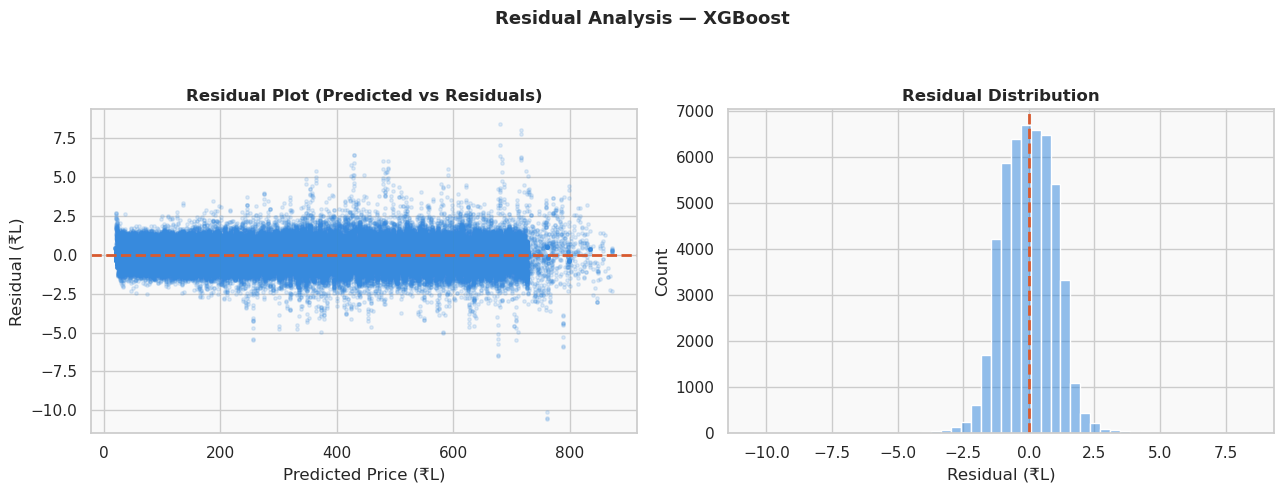

  Saved → models/best_regressor_XGBoost.pkl


In [83]:
residuals = y_reg_test.values - y_pred_best
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_pred_best, residuals, alpha=0.15, s=6, color=BLUE)
axes[0].axhline(0, color=CORAL, lw=2, linestyle="--")
axes[0].set_title("Residual Plot (Predicted vs Residuals)", fontweight="bold")
axes[0].set_xlabel("Predicted Price (₹L)"); axes[0].set_ylabel("Residual (₹L)")
axes[1].hist(residuals, bins=50, color=BLUE+"88", edgecolor="white")
axes[1].axvline(0, color=CORAL, lw=2, linestyle="--")
axes[1].set_title("Residual Distribution", fontweight="bold")
axes[1].set_xlabel("Residual (₹L)"); axes[1].set_ylabel("Count")
fig.suptitle(f"Residual Analysis — {best_reg_name}", fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("plots/residual_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"  Saved → models/best_regressor_{best_reg_name.replace(' ','_')}.pkl")